### 1. 데이터 불러오기

In [1]:
import numpy as np

# 저장된 배열 불러오기
final_embeddings_3 = np.load('book_embeddings_3.npy')
labels_3 = np.load('book_labels_3.npy')
final_embeddings_33 = np.load('book_embeddings_33.npy')
labels_33 = np.load('book_labels_33.npy')
final_embeddings_333 = np.load('book_embeddings_333.npy')
labels_333 = np.load('book_labels_333.npy')
labels_333

array([0, 0, 0, ..., 0, 0, 1])

In [2]:
# 저장된 데이터 불러오기
train_embeddings = np.load('train_book_embeddings_3.npy')
train_labels = np.load('train_book_labels_3.npy')

test_embeddings = np.load('test_book_embeddings_3.npy')
test_labels = np.load('test_book_labels_3.npy')

##### Modeling

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.activation = nn.ReLU()  # 추가

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        out = self.activation(out)  # 활성화 함수 추가
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        if len(out.shape) == 3:
            out = self.fc(out[:, -1, :])  # 3차원 텐서일 때 마지막 시점의 출력을 사용
        else:
            out = self.fc(out)  # 2차원 텐서일 경우 바로 fully connected layer로 보냄
        return out


# GRU 모델 정의
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.gru(x)
        if len(out.shape) == 3:
            out = self.fc(out[:, -1, :])  # 3차원 텐서일 경우 마지막 시점의 출력을 사용
        else:
            out = self.fc(out)  # 2차원 텐서일 경우 바로 fully connected layer로 보냄
        return out


class TextCNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(TextCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=3)
        self.conv2 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=4)
        self.conv3 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=5)
        self.fc = nn.Linear(300, output_dim)  # Conv 출력 차원 수에 따라 변경

    def forward(self, x):
        # TextCNN을 위한 입력 형태 변환
        x = x.unsqueeze(1)  # (Batch_size, 1, Input_dim)으로 변환
        x1 = nn.functional.relu(self.conv1(x))
        x2 = nn.functional.relu(self.conv2(x))
        x3 = nn.functional.relu(self.conv3(x))
        
        # 풀링과 연결
        x1 = nn.functional.max_pool1d(x1, x1.size(2)).view(-1, 100)
        x2 = nn.functional.max_pool1d(x2, x2.size(2)).view(-1, 100)
        x3 = nn.functional.max_pool1d(x3, x3.size(2)).view(-1, 100)
        
        x = torch.cat((x1, x2, x3), 1)  # Concatenate 풀링된 출력을
        out = self.fc(x)
        return out
    

# Transformer 모델 정의
class TransformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, nhead=8, num_layers=3, dim_feedforward=256):
        super(TransformerModel, self).__init__()
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(input_dim, nhead, dim_feedforward),
            num_layers
        )
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = x.permute(1, 0, 2)  # Transformer에 맞게 (Seq_length, Batch, Features)로 변환
        x = self.encoder(x)
        x = x[-1, :, :]  # 마지막 시퀀스만 가져옴
        out = self.fc(x)
        return out


try

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True, dropout=0.3)
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.activation = nn.ReLU()  # 추가

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        out, _ = self.rnn(x)
        out = self.batch_norm(out[:, -1, :])
        out = self.fc(out[:, -1, :])
        out = self.activation(out)  # 활성화 함수 추가
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, dropout=0.3)
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        if len(out.shape) == 3:
            out = self.fc(out[:, -1, :])  # 3차원 텐서일 때 마지막 시점의 출력을 사용
        else:
            out = self.fc(out)  # 2차원 텐서일 경우 바로 fully connected layer로 보냄
        return out


# GRU 모델 정의
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, dropout=0.3)
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.batch_norm(out[:, -1, :])
        if len(out.shape) == 3:
            out = self.fc(out[:, -1, :])  # 3차원 텐서일 경우 마지막 시점의 출력을 사용
        else:
            out = self.fc(out)  # 2차원 텐서일 경우 바로 fully connected layer로 보냄
        return out


class TextCNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(TextCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=3)
        self.conv2 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=4)
        self.conv3 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=5)
        self.fc = nn.Linear(300, output_dim)  # Conv 출력 차원 수에 따라 변경

    def forward(self, x):
        # TextCNN을 위한 입력 형태 변환
        x = x.unsqueeze(1)  # (Batch_size, 1, Input_dim)으로 변환
        x1 = nn.functional.relu(self.conv1(x))
        x2 = nn.functional.relu(self.conv2(x))
        x3 = nn.functional.relu(self.conv3(x))
        
        # 풀링과 연결
        x1 = nn.functional.max_pool1d(x1, x1.size(2)).view(-1, 100)
        x2 = nn.functional.max_pool1d(x2, x2.size(2)).view(-1, 100)
        x3 = nn.functional.max_pool1d(x3, x3.size(2)).view(-1, 100)
        
        x = torch.cat((x1, x2, x3), 1)
        out = self.fc(x)
        return out
    

# Transformer 모델 정의
class TransformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, nhead=8, num_layers=3, dim_feedforward=256):
        super(TransformerModel, self).__init__()
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(input_dim, nhead, dim_feedforward, dropout=0.3),
            num_layers
        )
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = x.permute(1, 0, 2)  # Transformer에 맞게 (Seq_length, Batch, Features)로 변환
        x = self.encoder(x)
        x = x[-1, :, :]  # 마지막 시퀀스만 가져옴
        out = self.fc(x)
        return out


In [4]:
# 모델 학습 함수 정의
def train_model(model, final_embeddings, labels, X_val, y_val, epochs=10, batch_size=64):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        for i in range(0, len(final_embeddings), batch_size):
            batch_x = torch.tensor(final_embeddings[i:i + batch_size], dtype=torch.float32).to(device)
            batch_y = torch.tensor(labels[i:i + batch_size], dtype=torch.float32).to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y.view(-1, 1))
            loss.backward()
            optimizer.step()

        # Validation step
        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.tensor(X_val, dtype=torch.float32).to(device))
            val_loss = criterion(val_outputs, torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device))
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}], Validation Loss: {val_loss.item():.4f}")

In [5]:
from sklearn.metrics import confusion_matrix

# 성능 평가 함수 정의 (Specificity 포함)
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(torch.tensor(X_test, dtype=torch.float32).to(device))
        preds = torch.sigmoid(outputs).cpu().numpy()
        preds_binary = (preds > 0.5).astype(int)

    report = classification_report(y_test, preds_binary, output_dict=True)
    auc_roc = roc_auc_score(y_test, preds)
    
    # Confusion matrix를 사용하여 Specificity 계산
    tn, fp, fn, tp = confusion_matrix(y_test, preds_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # 분모가 0이 되지 않도록 처리

    return report, auc_roc, specificity

0. logistic regression

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd
import random
import torch

def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    random.seed(seed)

def evaluate_model(model, X, y):
    """모델 평가 함수"""
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Classification report
    report = classification_report(y, y_pred, output_dict=True)
    
    # AUC-ROC
    auc_roc = roc_auc_score(y, y_pred_proba)
    
    # Specificity 계산
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    return report, auc_roc, specificity

# K-Fold 및 시드 설정
k = 5  # K-Fold의 개수
seed = 42
seed_everything(seed)

# 데이터 준비
X = final_embeddings_3  # 임베딩 데이터
y = labels_3  # 라벨

# Stratified K-Fold 설정
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 성능 저장용 데이터프레임 초기화
performance_df = pd.DataFrame()

# 모델 학습 및 평가
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 시드 고정
    seed_everything(seed)
    
    # Fold 데이터 분리
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]
    
    # Logistic Regression 모델 초기화
    logreg_model = LogisticRegression(random_state=seed, max_iter=100)
    
    # 모델 학습
    logreg_model.fit(X_fold_train, y_fold_train)
    
    # Train 성능 평가
    logreg_train_report, logreg_train_auc, logreg_train_specificity = evaluate_model(logreg_model, X_fold_train, y_fold_train)
    
    # Validation 성능 평가
    logreg_val_report, logreg_val_auc, logreg_val_specificity = evaluate_model(logreg_model, X_fold_val, y_fold_val)
    
    # Train 성능 결과 저장
    train_row = pd.DataFrame({
        'Model': ['LogisticRegression'],
        'Fold': [fold + 1],
        'Dataset': ['Train'],
        'Accuracy': [logreg_train_report['accuracy']],
        'F1-Score': [logreg_train_report['1']['f1-score']],
        'Precision': [logreg_train_report['1']['precision']],
        'Recall': [logreg_train_report['1']['recall']],
        'AUC-ROC': [logreg_train_auc],
        'Specificity': [logreg_train_specificity]
    })
    performance_df = pd.concat([performance_df, train_row], ignore_index=True)
    
    # Validation 성능 결과 저장
    val_row = pd.DataFrame({
        'Model': ['LogisticRegression'],
        'Fold': [fold + 1],
        'Dataset': ['Validation'],
        'Accuracy': [logreg_val_report['accuracy']],
        'F1-Score': [logreg_val_report['1']['f1-score']],
        'Precision': [logreg_val_report['1']['precision']],
        'Recall': [logreg_val_report['1']['recall']],
        'AUC-ROC': [logreg_val_auc],
        'Specificity': [logreg_val_specificity]
    })
    performance_df = pd.concat([performance_df, val_row], ignore_index=True)

# 성능 데이터프레임 출력
performance_df

/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,LogisticRegression,1,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,LogisticRegression,1,Validation,0.816577,0.637329,0.630631,0.644172,0.853024,0.874104
2,LogisticRegression,2,Train,0.999808,0.999616,0.999233,1.000000,1.000000,0.999744
3,LogisticRegression,2,Validation,0.813507,0.640000,0.618911,0.662577,0.847590,0.863869
4,LogisticRegression,3,Train,0.999808,0.999616,0.999233,1.000000,1.000000,0.999744
5,LogisticRegression,3,Validation,0.795088,0.603269,0.585014,0.622699,0.830233,0.852610
6,LogisticRegression,4,Train,0.999808,0.999617,0.999234,1.000000,1.000000,0.999744
7,LogisticRegression,4,Validation,0.818740,0.638037,0.636086,0.640000,0.850506,0.878199
8,LogisticRegression,5,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,LogisticRegression,5,Validation,0.807220,0.610853,0.617555,0.604294,0.847842,0.875000


In [6]:
performance_df[performance_df['Dataset'] == 'Train']

NameError: name 'performance_df' is not defined

In [7]:
performance_df[performance_df['Dataset'] == 'Validation']

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
1,LogisticRegression,1,Validation,0.816577,0.637329,0.630631,0.644172,0.853024,0.874104
3,LogisticRegression,2,Validation,0.813507,0.640000,0.618911,0.662577,0.847590,0.863869
5,LogisticRegression,3,Validation,0.795088,0.603269,0.585014,0.622699,0.830233,0.852610
7,LogisticRegression,4,Validation,0.818740,0.638037,0.636086,0.640000,0.850506,0.878199
9,LogisticRegression,5,Validation,0.807220,0.610853,0.617555,0.604294,0.847842,0.875000


1. RNN

- 모델 및 cv seed값 고정

In [7]:
performance_df_val = pd.DataFrame([])
performance_df = pd.DataFrame([])

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch
import random

def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    random.seed(seed)
    
k = 10  # K-Fold의 개수
# 시드 고정
seed = 42
seed_everything(seed)
# 데이터 분할
X = final_embeddings_3  # 임베딩
y = labels_3 # 라벨

# Stratified K-Fold 설정
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

# 데이터 정규화 (필요시)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 모델 학습 코드의 반복문 내 시드 고정
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 각 fold마다 시드 고정 (필요 시)
    seed_everything(seed)
    
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # RNN 모델 초기화
    rnn_model = RNNModel(input_dim=X.shape[1], hidden_dim=128, output_dim=1)

    # 모델 학습
    train_model(rnn_model, X_fold_train, y_fold_train, X_fold_val, y_fold_val)

    # Train 성능 평가
    rnn_train_report, rnn_train_auc, rnn_train_specificity = evaluate_model(rnn_model, X_fold_train, y_fold_train)
    
    # Validation 성능 평가
    rnn_val_report, rnn_val_auc, rnn_val_specificity = evaluate_model(rnn_model, X_fold_val, y_fold_val)
    
    # Train 성능 결과 저장
    train_row = pd.DataFrame({
        'Model': ['RNN'],
        'Fold': [fold + 1],
        'Dataset': ['Train'],
        'Accuracy': [rnn_train_report['accuracy']],
        'F1-Score': [rnn_train_report['1']['f1-score']],
        'Precision': [rnn_train_report['1']['precision']],
        'Recall': [rnn_train_report['1']['recall']],
        'AUC-ROC': [rnn_train_auc],
        'Specificity': [rnn_train_specificity]
    })
    performance_df = pd.concat([performance_df, train_row], ignore_index=True)
    
    # Validation 성능 결과 저장
    val_row = pd.DataFrame({
        'Model': ['RNN'],
        'Fold': [fold + 1],
        'Dataset': ['Validation'],
        'Accuracy': [rnn_val_report['accuracy']],
        'F1-Score': [rnn_val_report['1']['f1-score']],
        'Precision': [rnn_val_report['1']['precision']],
        'Recall': [rnn_val_report['1']['recall']],
        'AUC-ROC': [rnn_val_auc],
        'Specificity': [rnn_val_specificity]
    })
    performance_df_val = pd.concat([performance_df_val, val_row], ignore_index=True)

# 성능 데이터프레임 출력
performance_df

Epoch [10/10], Validation Loss: 0.6811
Epoch [10/10], Validation Loss: 0.6980
Epoch [10/10], Validation Loss: 0.6910
Epoch [10/10], Validation Loss: 0.6854
Epoch [10/10], Validation Loss: 0.7161
Epoch [10/10], Validation Loss: 0.6754
Epoch [10/10], Validation Loss: 0.6834
Epoch [10/10], Validation Loss: 0.6769
Epoch [10/10], Validation Loss: 0.6814
Epoch [10/10], Validation Loss: 0.6879


,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,RNN,1,Train,0.911634,0.833761,0.787273,0.886085,0.937725,0.920155
1,RNN,2,Train,0.915728,0.840542,0.797794,0.888131,0.939152,0.924932
2,RNN,3,Train,0.920846,0.848663,0.813125,0.887449,0.939248,0.931984
3,RNN,4,Train,0.913852,0.837464,0.792809,0.887449,0.938749,0.922657
4,RNN,5,Train,0.916937,0.842446,0.801724,0.887526,0.939116,0.926752
5,RNN,6,Train,0.913696,0.836774,0.793758,0.884720,0.937111,0.923357
6,RNN,7,Train,0.919325,0.846179,0.808577,0.887449,0.939049,0.929952
7,RNN,8,Train,0.920177,0.847755,0.810323,0.888813,0.939832,0.930635
8,RNN,9,Train,0.915913,0.838731,0.805783,0.874488,0.932380,0.929725
9,RNN,10,Train,0.911138,0.833493,0.784125,0.889495,0.939330,0.918353


In [9]:
performance_df_val

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,RNN,1,Validation,0.771472,0.635697,0.528455,0.797546,0.828014,0.762781
1,RNN,2,Validation,0.746933,0.615385,0.496241,0.809816,0.820286,0.725971
2,RNN,3,Validation,0.777607,0.663573,0.533582,0.877301,0.858068,0.744376
3,RNN,4,Validation,0.740798,0.621924,0.489437,0.852761,0.851832,0.703476
4,RNN,5,Validation,0.735791,0.596244,0.481061,0.783951,0.794592,0.719836
5,RNN,6,Validation,0.780338,0.657074,0.539370,0.840491,0.851240,0.760246
6,RNN,7,Validation,0.775730,0.652381,0.533074,0.840491,0.848134,0.754098
7,RNN,8,Validation,0.772657,0.660550,0.527473,0.883436,0.870581,0.735656
8,RNN,9,Validation,0.780338,0.674260,0.536232,0.907975,0.885070,0.737705
9,RNN,10,Validation,0.752688,0.638202,0.503546,0.871166,0.855979,0.713115


In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch
import random

def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    random.seed(seed)
    
k = 10  # K-Fold의 개수
# 시드 고정
seed = 42
seed_everything(seed)
# 데이터 분할
X = final_embeddings_3  # 임베딩
y = labels_3 # 라벨

# Stratified K-Fold 설정
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

# 데이터 정규화 (필요시)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 모델 학습 코드의 반복문 내 시드 고정
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 각 fold마다 시드 고정 (필요 시)
    seed_everything(seed)
    
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # RNN 모델 초기화
    rnn_model = RNNModel(input_dim=X.shape[1], hidden_dim=128, output_dim=1)

    # 모델 학습
    train_model(rnn_model, X_fold_train, y_fold_train, X_fold_val, y_fold_val)

    # Train 성능 평가
    rnn_train_report, rnn_train_auc, rnn_train_specificity = evaluate_model(rnn_model, X_fold_train, y_fold_train)
    
    # Validation 성능 평가
    rnn_val_report, rnn_val_auc, rnn_val_specificity = evaluate_model(rnn_model, X_fold_val, y_fold_val)
    
    # Train 성능 결과 저장
    train_row = pd.DataFrame({
        'Model': ['RNN'],
        'Fold': [fold + 1],
        'Dataset': ['Train'],
        'Accuracy': [rnn_train_report['accuracy']],
        'F1-Score': [rnn_train_report['1']['f1-score']],
        'Precision': [rnn_train_report['1']['precision']],
        'Recall': [rnn_train_report['1']['recall']],
        'AUC-ROC': [rnn_train_auc],
        'Specificity': [rnn_train_specificity]
    })
    performance_df = pd.concat([performance_df, train_row], ignore_index=True)
    
    # Validation 성능 결과 저장
    val_row = pd.DataFrame({
        'Model': ['RNN'],
        'Fold': [fold + 1],
        'Dataset': ['Validation'],
        'Accuracy': [rnn_val_report['accuracy']],
        'F1-Score': [rnn_val_report['1']['f1-score']],
        'Precision': [rnn_val_report['1']['precision']],
        'Recall': [rnn_val_report['1']['recall']],
        'AUC-ROC': [rnn_val_auc],
        'Specificity': [rnn_val_specificity]
    })
    performance_df_val = pd.concat([performance_df_val, val_row], ignore_index=True)

# 성능 데이터프레임 출력
performance_df

Epoch [10/40], Validation Loss: 0.7024
Epoch [20/40], Validation Loss: 0.7195
Epoch [30/40], Validation Loss: 0.7376
Epoch [40/40], Validation Loss: 0.7354
Epoch [10/40], Validation Loss: 0.6789
Epoch [20/40], Validation Loss: 0.7204
Epoch [30/40], Validation Loss: 0.7127
Epoch [40/40], Validation Loss: 0.7211
Epoch [10/40], Validation Loss: 0.7032
Epoch [20/40], Validation Loss: 0.7101
Epoch [30/40], Validation Loss: 0.7013
Epoch [40/40], Validation Loss: 0.7310
Epoch [10/40], Validation Loss: 0.7035
Epoch [20/40], Validation Loss: 0.7243
Epoch [30/40], Validation Loss: 0.7039
Epoch [40/40], Validation Loss: 0.7115
Epoch [10/40], Validation Loss: 0.6983
Epoch [20/40], Validation Loss: 0.7307
Epoch [30/40], Validation Loss: 0.7229
Epoch [40/40], Validation Loss: 0.7443
Epoch [10/40], Validation Loss: 0.7329
Epoch [20/40], Validation Loss: 0.7705
Epoch [30/40], Validation Loss: 0.7651
Epoch [40/40], Validation Loss: 0.7806
Epoch [10/40], Validation Loss: 0.6983
Epoch [20/40], Validation

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,RNN,1,Train,0.965194,0.927762,0.964654,0.893588,0.946193,0.989078
1,RNN,2,Train,0.965706,0.929151,0.961342,0.899045,0.948848,0.987941
2,RNN,3,Train,0.962634,0.922258,0.961510,0.886085,0.942355,0.988168
3,RNN,4,Train,0.967417,0.931956,0.976119,0.891616,0.945388,0.992719
4,RNN,5,Train,0.964858,0.926429,0.972264,0.884720,0.941841,0.991583
5,RNN,6,Train,0.958547,0.914346,0.946025,0.884720,0.941301,0.983167
6,RNN,7,Train,0.960764,0.918382,0.957101,0.882674,0.940502,0.986806
7,RNN,8,Train,0.963494,0.924275,0.960294,0.890859,0.944736,0.987716
8,RNN,9,Train,0.968611,0.934936,0.970631,0.901774,0.950429,0.990901
9,RNN,10,Train,0.965200,0.927813,0.963971,0.894270,0.946539,0.988854


Epoch [10/100], Train Loss: 0.5750, Validation Loss: 0.7024, Validation Accuracy: 0.8144
Epoch [20/100], Train Loss: 0.5546, Validation Loss: 0.7195, Validation Accuracy: 0.8374
Epoch [30/100], Train Loss: 0.5529, Validation Loss: 0.7376, Validation Accuracy: 0.8344
Epoch [40/100], Train Loss: 0.5553, Validation Loss: 0.7354, Validation Accuracy: 0.8482
Epoch [50/100], Train Loss: 0.5502, Validation Loss: 0.7514, Validation Accuracy: 0.8344
Epoch [60/100], Train Loss: 0.5469, Validation Loss: 0.7864, Validation Accuracy: 0.8298
Epoch [70/100], Train Loss: 0.5468, Validation Loss: 0.7491, Validation Accuracy: 0.8328
Epoch [80/100], Train Loss: 0.5467, Validation Loss: 0.7616, Validation Accuracy: 0.8466
Epoch [90/100], Train Loss: 0.5472, Validation Loss: 0.7606, Validation Accuracy: 0.8206
Epoch [100/100], Train Loss: 0.5452, Validation Loss: 0.7719, Validation Accuracy: 0.8298


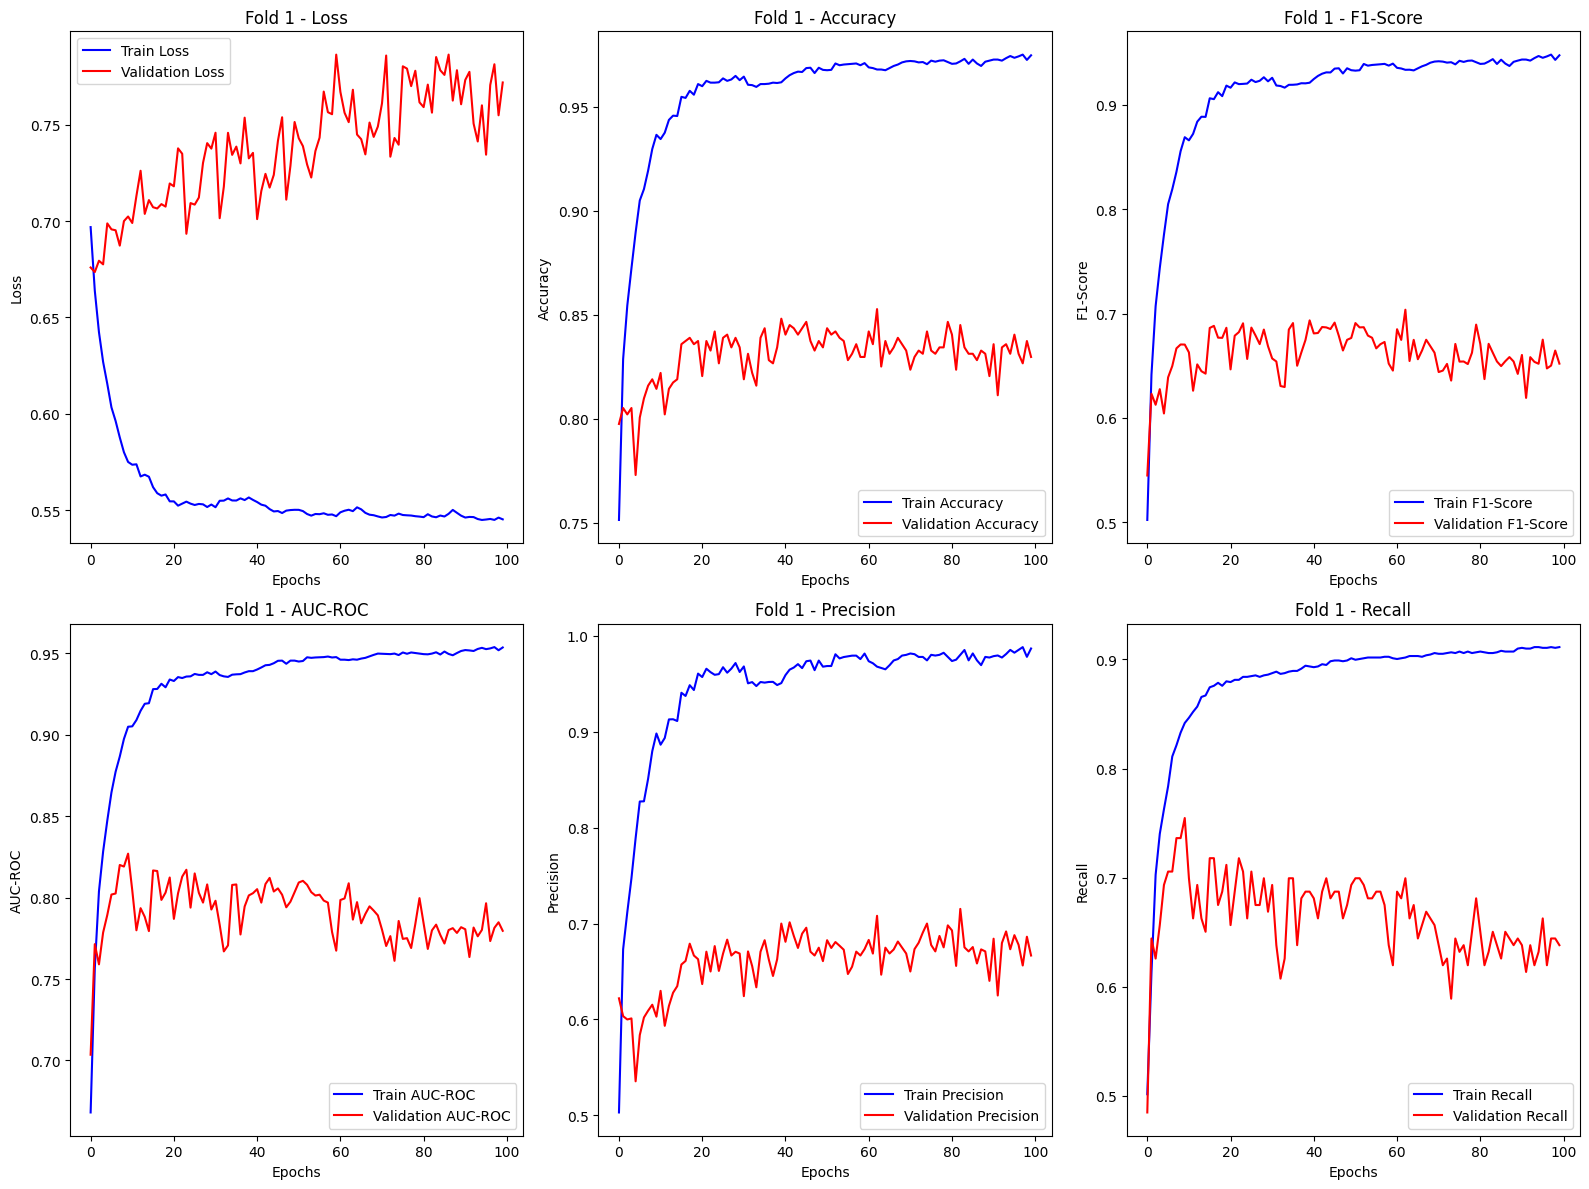

Epoch [10/100], Train Loss: 0.5818, Validation Loss: 0.6789, Validation Accuracy: 0.8190
Epoch [20/100], Train Loss: 0.5565, Validation Loss: 0.7204, Validation Accuracy: 0.8252
Epoch [30/100], Train Loss: 0.5525, Validation Loss: 0.7127, Validation Accuracy: 0.8374
Epoch [40/100], Train Loss: 0.5556, Validation Loss: 0.7211, Validation Accuracy: 0.8267
Epoch [50/100], Train Loss: 0.5485, Validation Loss: 0.7529, Validation Accuracy: 0.8190
Epoch [60/100], Train Loss: 0.5480, Validation Loss: 0.7612, Validation Accuracy: 0.8344
Epoch [70/100], Train Loss: 0.5492, Validation Loss: 0.7535, Validation Accuracy: 0.8252
Epoch [80/100], Train Loss: 0.5457, Validation Loss: 0.7748, Validation Accuracy: 0.8328
Epoch [90/100], Train Loss: 0.5448, Validation Loss: 0.7644, Validation Accuracy: 0.8298
Epoch [100/100], Train Loss: 0.5442, Validation Loss: 0.7683, Validation Accuracy: 0.8298


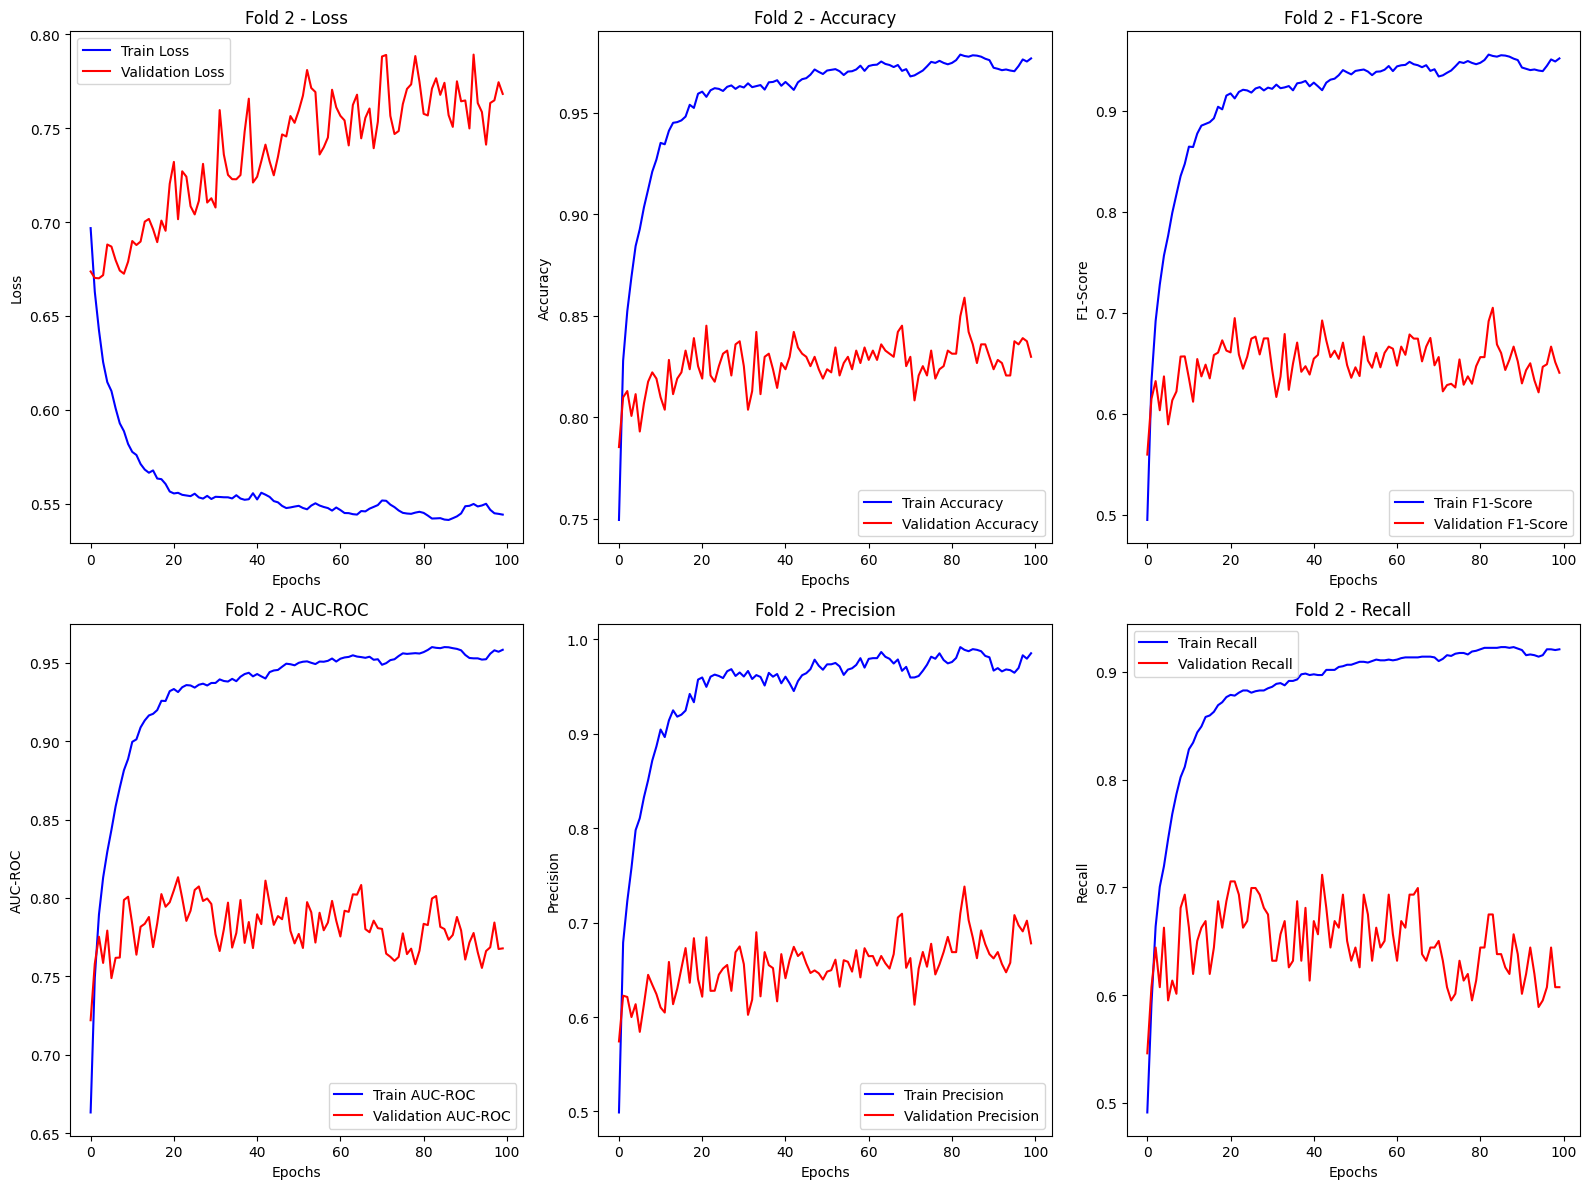

Epoch [10/100], Train Loss: 0.5823, Validation Loss: 0.7032, Validation Accuracy: 0.8206
Epoch [20/100], Train Loss: 0.5633, Validation Loss: 0.7101, Validation Accuracy: 0.8497
Epoch [30/100], Train Loss: 0.5539, Validation Loss: 0.7013, Validation Accuracy: 0.8558
Epoch [40/100], Train Loss: 0.5549, Validation Loss: 0.7310, Validation Accuracy: 0.8359
Epoch [50/100], Train Loss: 0.5505, Validation Loss: 0.7171, Validation Accuracy: 0.8512
Epoch [60/100], Train Loss: 0.5512, Validation Loss: 0.7382, Validation Accuracy: 0.8497
Epoch [70/100], Train Loss: 0.5482, Validation Loss: 0.7317, Validation Accuracy: 0.8436
Epoch [80/100], Train Loss: 0.5509, Validation Loss: 0.7309, Validation Accuracy: 0.8512
Epoch [90/100], Train Loss: 0.5468, Validation Loss: 0.7882, Validation Accuracy: 0.8252
Epoch [100/100], Train Loss: 0.5487, Validation Loss: 0.7812, Validation Accuracy: 0.8451


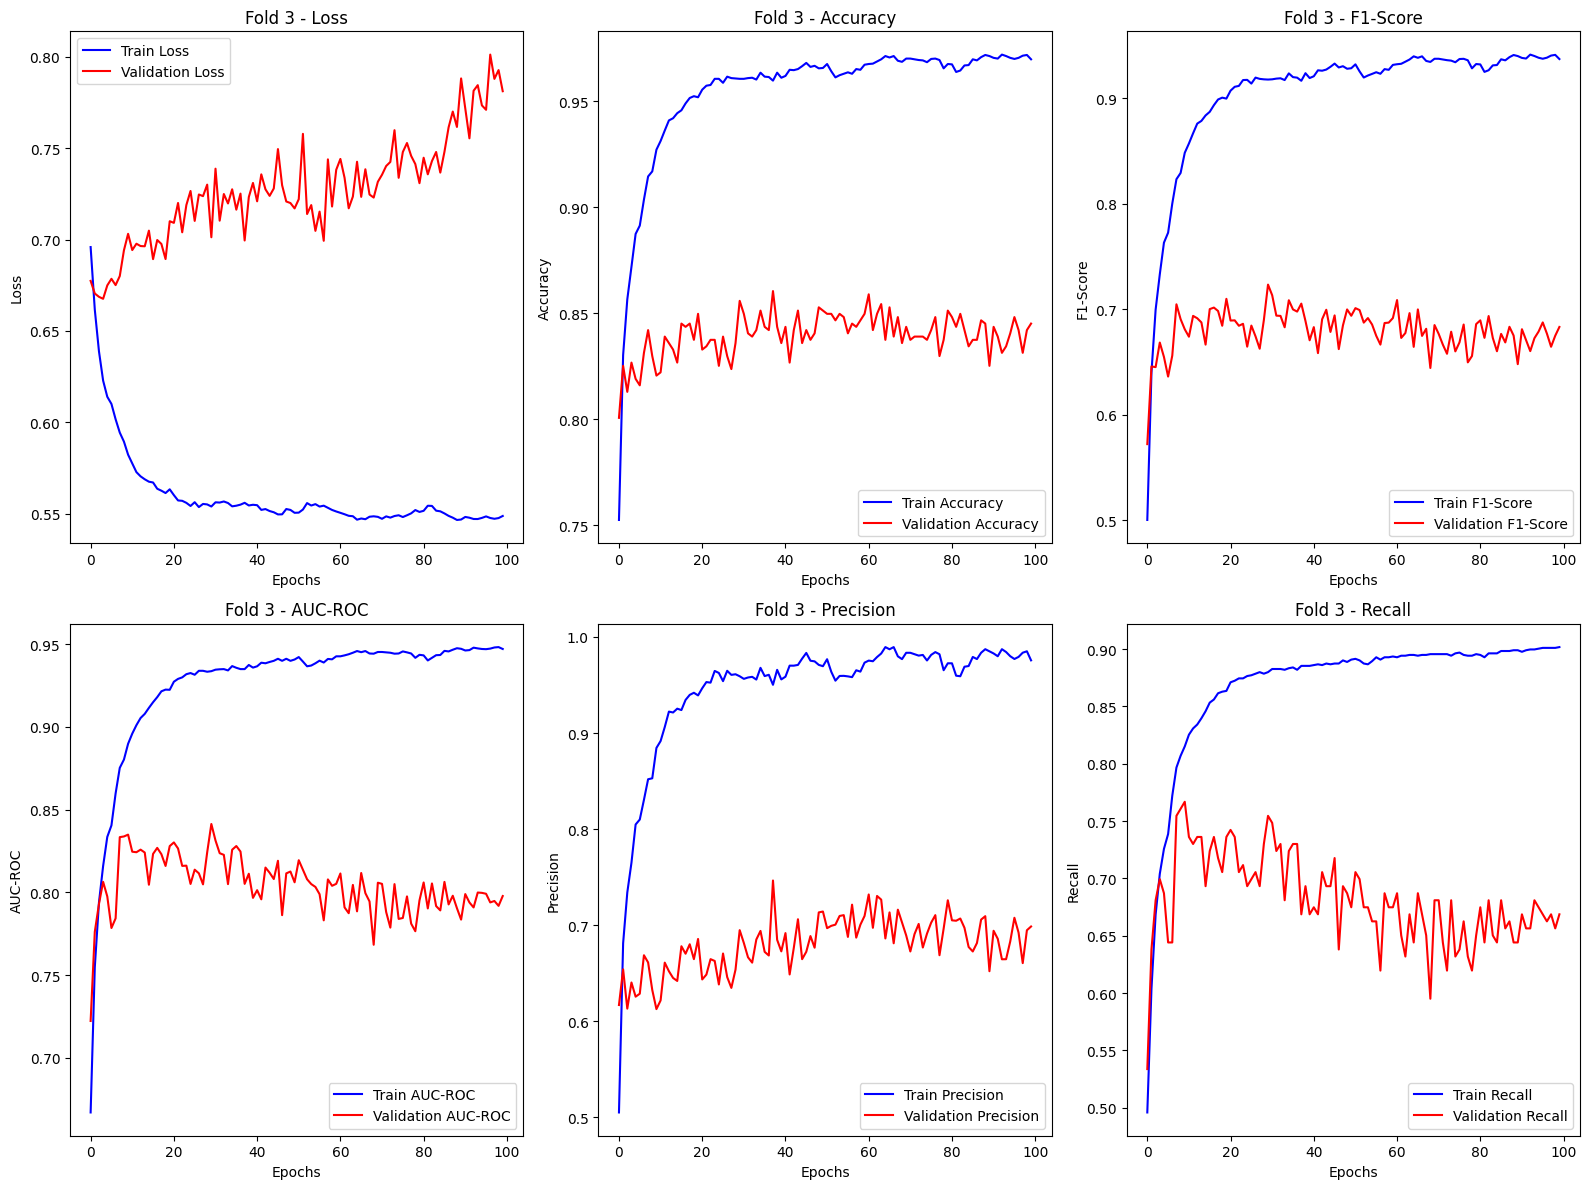

Epoch [10/100], Train Loss: 0.5827, Validation Loss: 0.7035, Validation Accuracy: 0.8111
Epoch [20/100], Train Loss: 0.5574, Validation Loss: 0.7243, Validation Accuracy: 0.8280
Epoch [30/100], Train Loss: 0.5587, Validation Loss: 0.7039, Validation Accuracy: 0.8372
Epoch [40/100], Train Loss: 0.5513, Validation Loss: 0.7115, Validation Accuracy: 0.8510
Epoch [50/100], Train Loss: 0.5512, Validation Loss: 0.7290, Validation Accuracy: 0.8341
Epoch [60/100], Train Loss: 0.5496, Validation Loss: 0.7459, Validation Accuracy: 0.8495
Epoch [70/100], Train Loss: 0.5484, Validation Loss: 0.7454, Validation Accuracy: 0.8387
Epoch [80/100], Train Loss: 0.5478, Validation Loss: 0.7333, Validation Accuracy: 0.8464
Epoch [90/100], Train Loss: 0.5531, Validation Loss: 0.7189, Validation Accuracy: 0.8495
Epoch [100/100], Train Loss: 0.5443, Validation Loss: 0.7427, Validation Accuracy: 0.8433


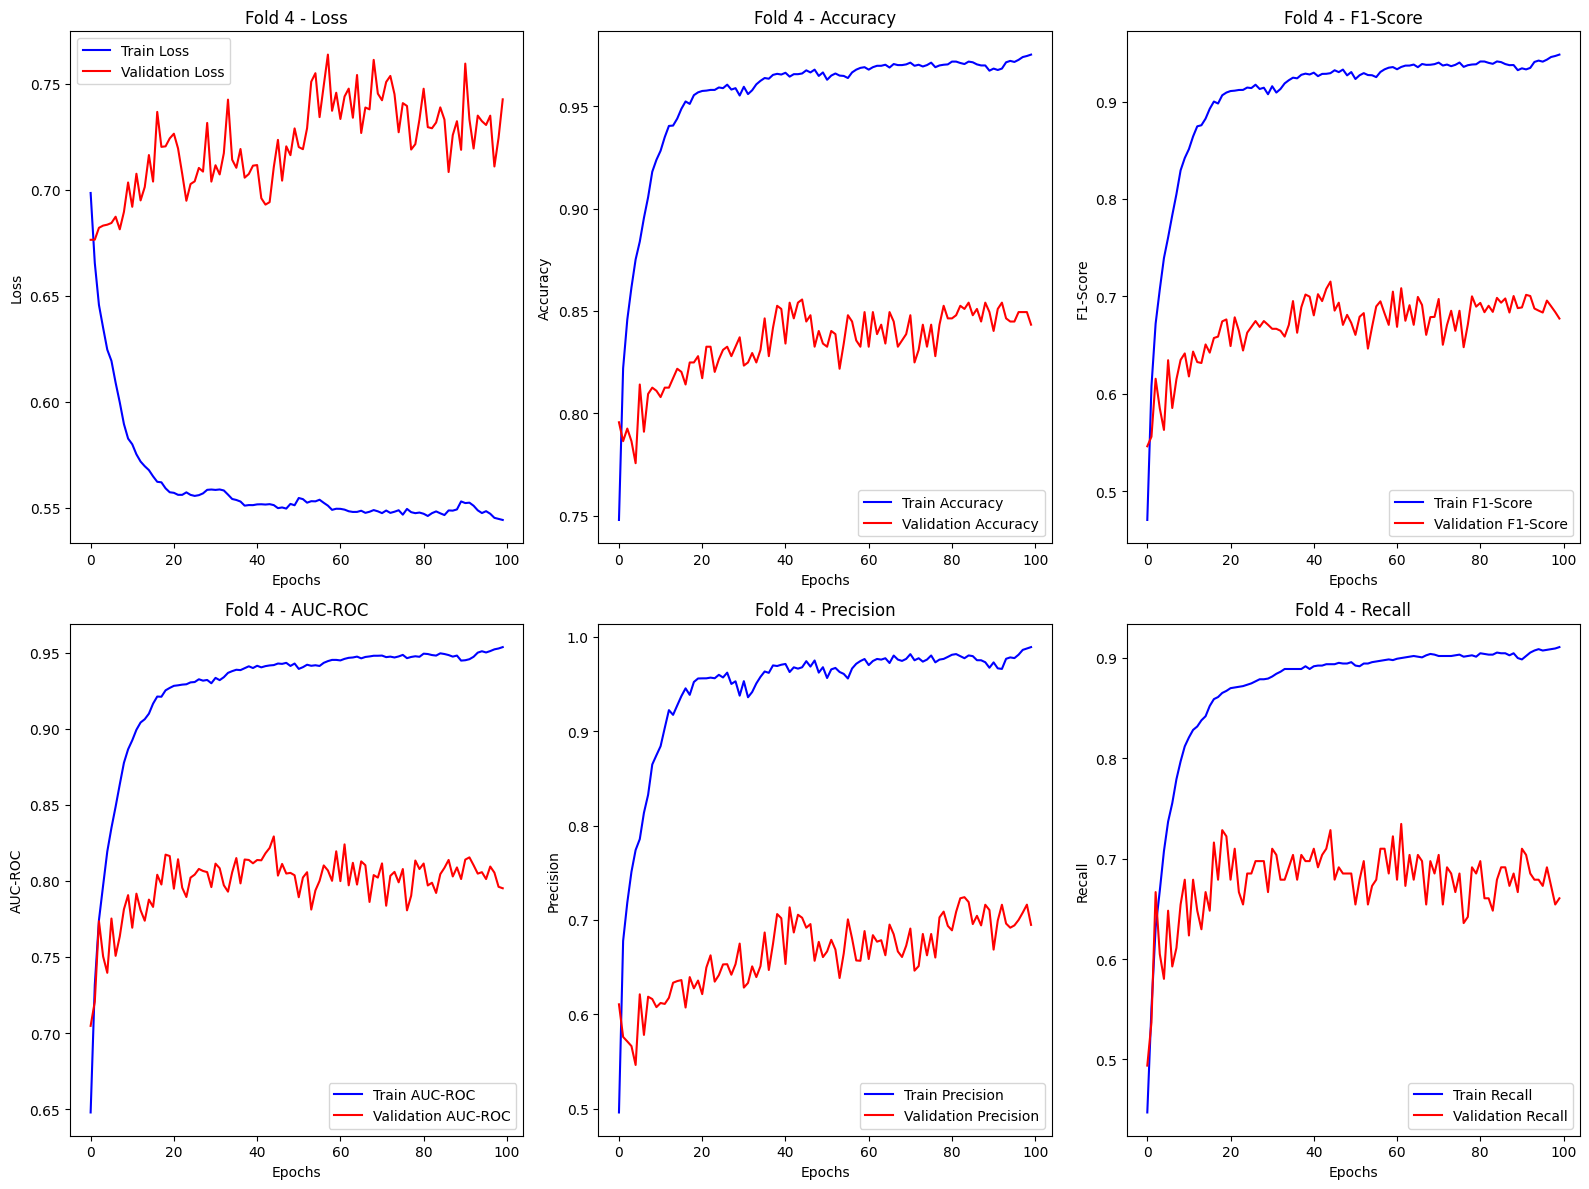

Epoch [10/100], Train Loss: 0.5846, Validation Loss: 0.6983, Validation Accuracy: 0.8141
Epoch [20/100], Train Loss: 0.5575, Validation Loss: 0.7307, Validation Accuracy: 0.8295
Epoch [30/100], Train Loss: 0.5550, Validation Loss: 0.7229, Validation Accuracy: 0.8433
Epoch [40/100], Train Loss: 0.5565, Validation Loss: 0.7443, Validation Accuracy: 0.8387
Epoch [50/100], Train Loss: 0.5521, Validation Loss: 0.7340, Validation Accuracy: 0.8418
Epoch [60/100], Train Loss: 0.5470, Validation Loss: 0.7479, Validation Accuracy: 0.8372
Epoch [70/100], Train Loss: 0.5500, Validation Loss: 0.7720, Validation Accuracy: 0.8387
Epoch [80/100], Train Loss: 0.5495, Validation Loss: 0.7497, Validation Accuracy: 0.8341
Epoch [90/100], Train Loss: 0.5462, Validation Loss: 0.7562, Validation Accuracy: 0.8464
Epoch [100/100], Train Loss: 0.5445, Validation Loss: 0.7734, Validation Accuracy: 0.8295


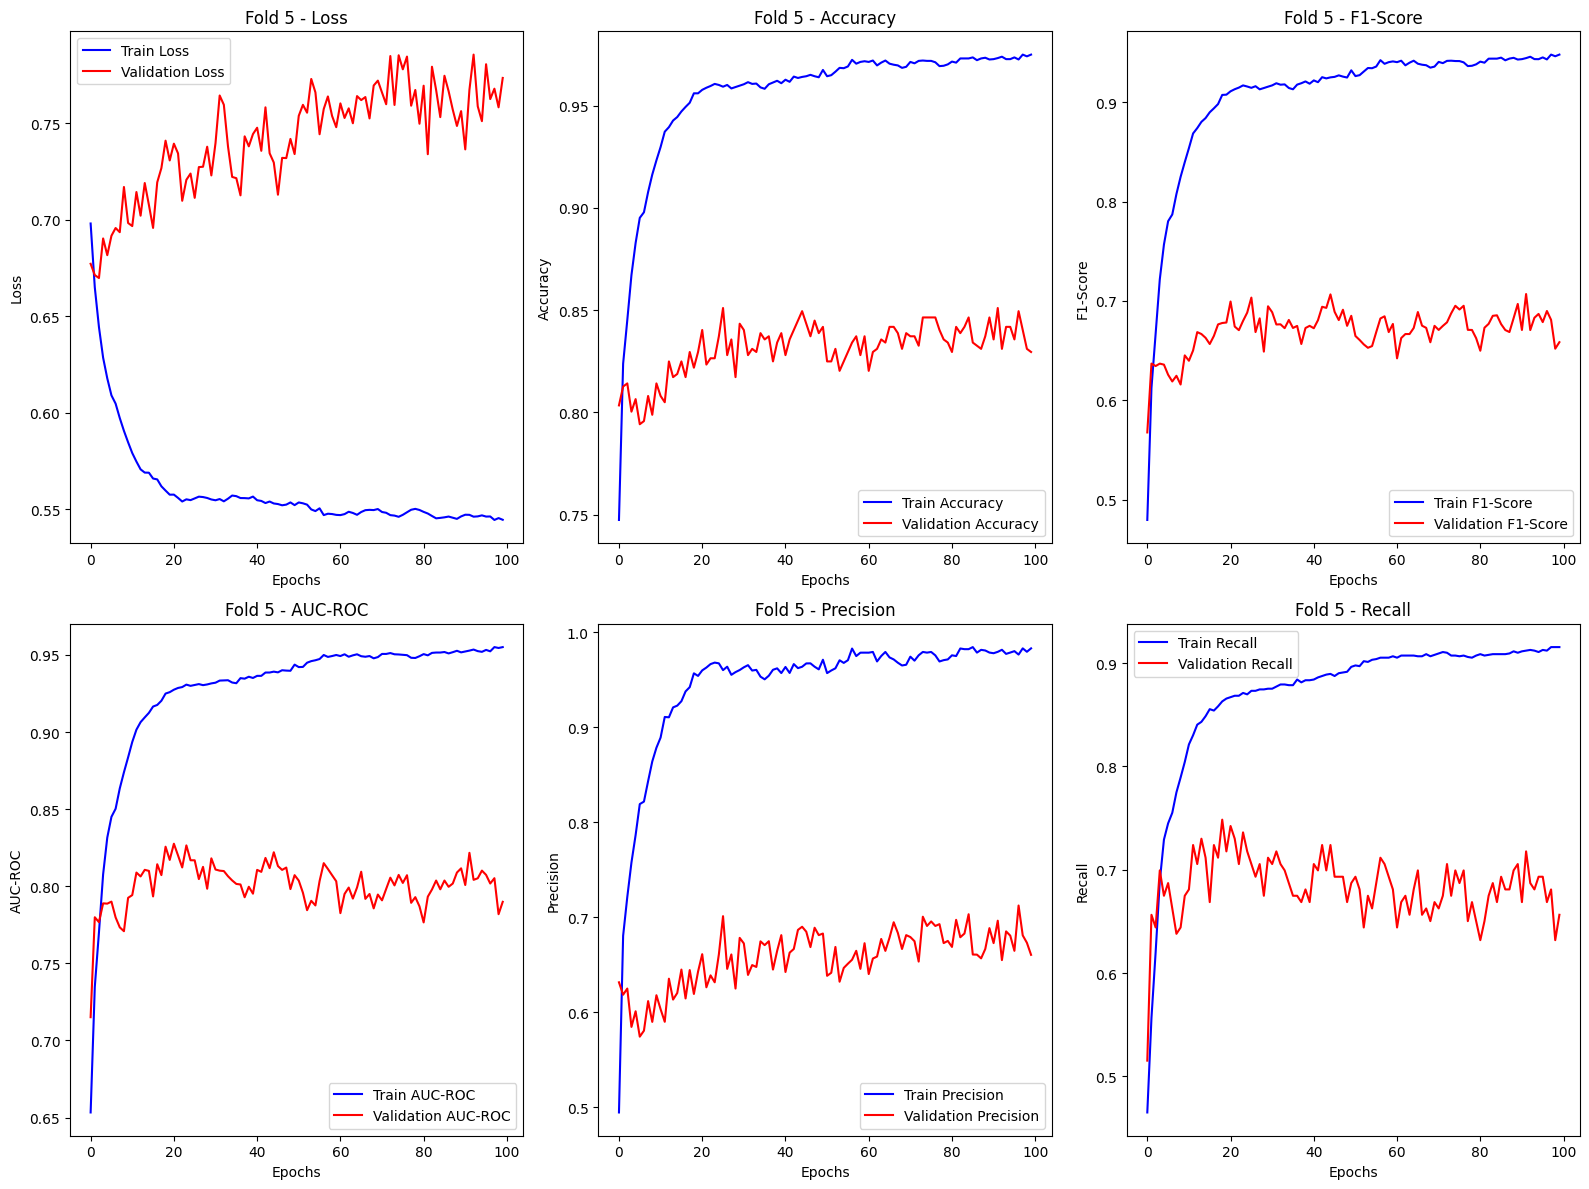

Epoch [10/100], Train Loss: 0.5818, Validation Loss: 0.7329, Validation Accuracy: 0.8203
Epoch [20/100], Train Loss: 0.5586, Validation Loss: 0.7705, Validation Accuracy: 0.8141
Epoch [30/100], Train Loss: 0.5536, Validation Loss: 0.7651, Validation Accuracy: 0.8203
Epoch [40/100], Train Loss: 0.5544, Validation Loss: 0.7806, Validation Accuracy: 0.8126
Epoch [50/100], Train Loss: 0.5526, Validation Loss: 0.8108, Validation Accuracy: 0.7988
Epoch [60/100], Train Loss: 0.5495, Validation Loss: 0.7925, Validation Accuracy: 0.8141
Epoch [70/100], Train Loss: 0.5493, Validation Loss: 0.7760, Validation Accuracy: 0.8141
Epoch [80/100], Train Loss: 0.5469, Validation Loss: 0.7631, Validation Accuracy: 0.8233
Epoch [90/100], Train Loss: 0.5499, Validation Loss: 0.7709, Validation Accuracy: 0.8172
Epoch [100/100], Train Loss: 0.5450, Validation Loss: 0.7874, Validation Accuracy: 0.8187


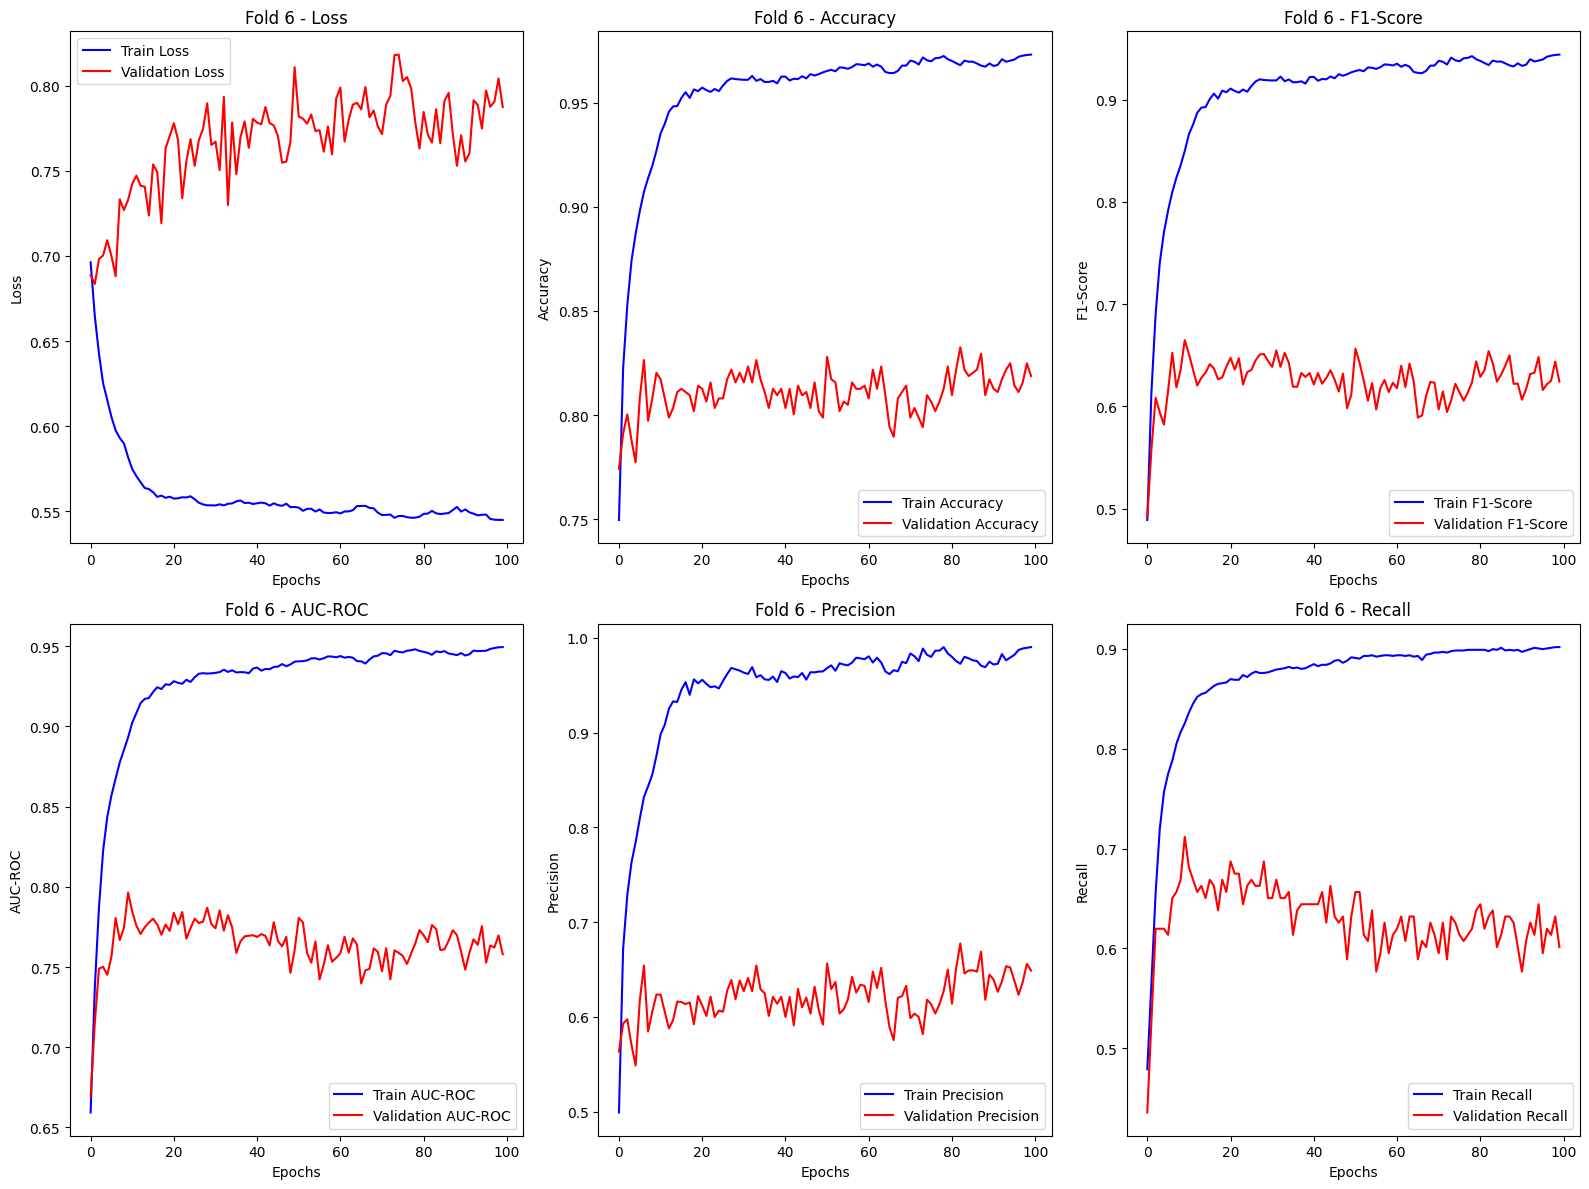

Epoch [10/100], Train Loss: 0.5831, Validation Loss: 0.6983, Validation Accuracy: 0.8326
Epoch [20/100], Train Loss: 0.5594, Validation Loss: 0.7335, Validation Accuracy: 0.8433
Epoch [30/100], Train Loss: 0.5562, Validation Loss: 0.7358, Validation Accuracy: 0.8433
Epoch [40/100], Train Loss: 0.5558, Validation Loss: 0.7307, Validation Accuracy: 0.8233
Epoch [50/100], Train Loss: 0.5508, Validation Loss: 0.7448, Validation Accuracy: 0.8218
Epoch [60/100], Train Loss: 0.5521, Validation Loss: 0.7423, Validation Accuracy: 0.8356
Epoch [70/100], Train Loss: 0.5480, Validation Loss: 0.7429, Validation Accuracy: 0.8387
Epoch [80/100], Train Loss: 0.5459, Validation Loss: 0.7493, Validation Accuracy: 0.8326
Epoch [90/100], Train Loss: 0.5485, Validation Loss: 0.7649, Validation Accuracy: 0.8356
Epoch [100/100], Train Loss: 0.5468, Validation Loss: 0.7847, Validation Accuracy: 0.8433


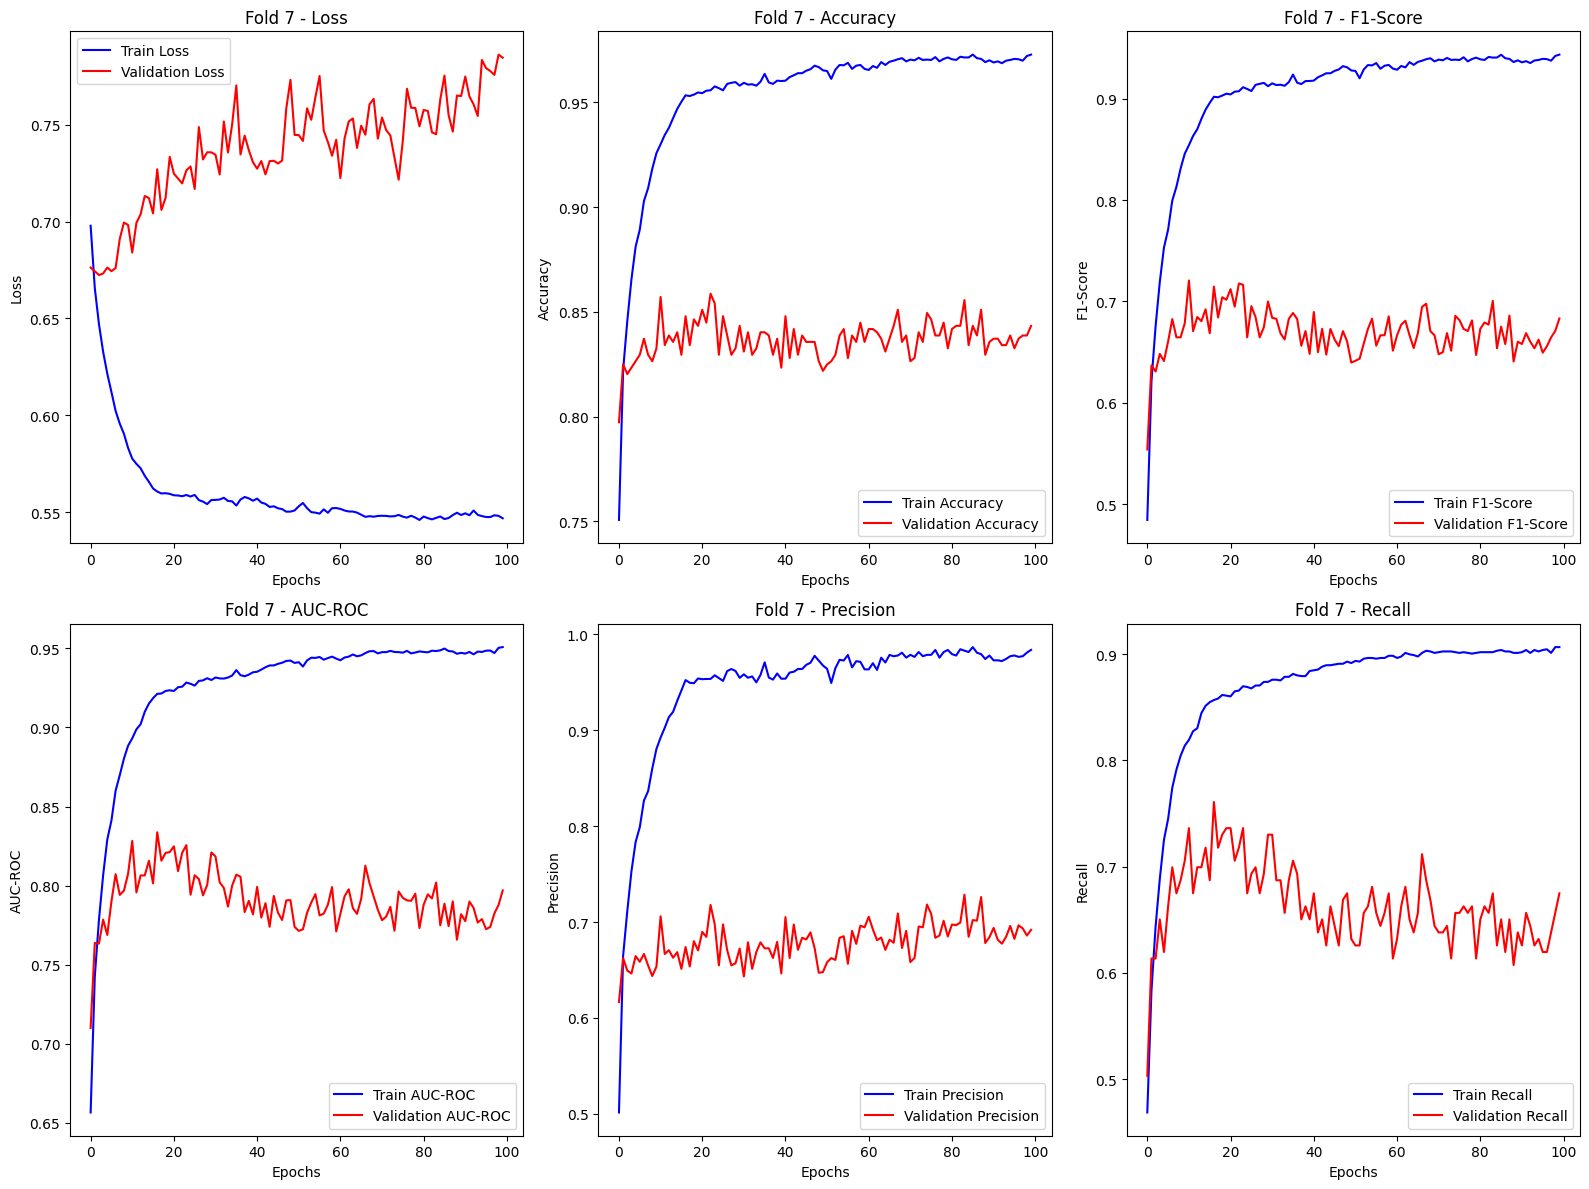

Epoch [10/100], Train Loss: 0.5823, Validation Loss: 0.6968, Validation Accuracy: 0.8218
Epoch [20/100], Train Loss: 0.5577, Validation Loss: 0.7220, Validation Accuracy: 0.8126
Epoch [30/100], Train Loss: 0.5557, Validation Loss: 0.7321, Validation Accuracy: 0.8264
Epoch [40/100], Train Loss: 0.5525, Validation Loss: 0.7359, Validation Accuracy: 0.8034
Epoch [50/100], Train Loss: 0.5504, Validation Loss: 0.7263, Validation Accuracy: 0.8341
Epoch [60/100], Train Loss: 0.5483, Validation Loss: 0.7602, Validation Accuracy: 0.8233
Epoch [70/100], Train Loss: 0.5506, Validation Loss: 0.7694, Validation Accuracy: 0.8218
Epoch [80/100], Train Loss: 0.5458, Validation Loss: 0.7773, Validation Accuracy: 0.8372
Epoch [90/100], Train Loss: 0.5484, Validation Loss: 0.7672, Validation Accuracy: 0.8203
Epoch [100/100], Train Loss: 0.5477, Validation Loss: 0.7515, Validation Accuracy: 0.8280


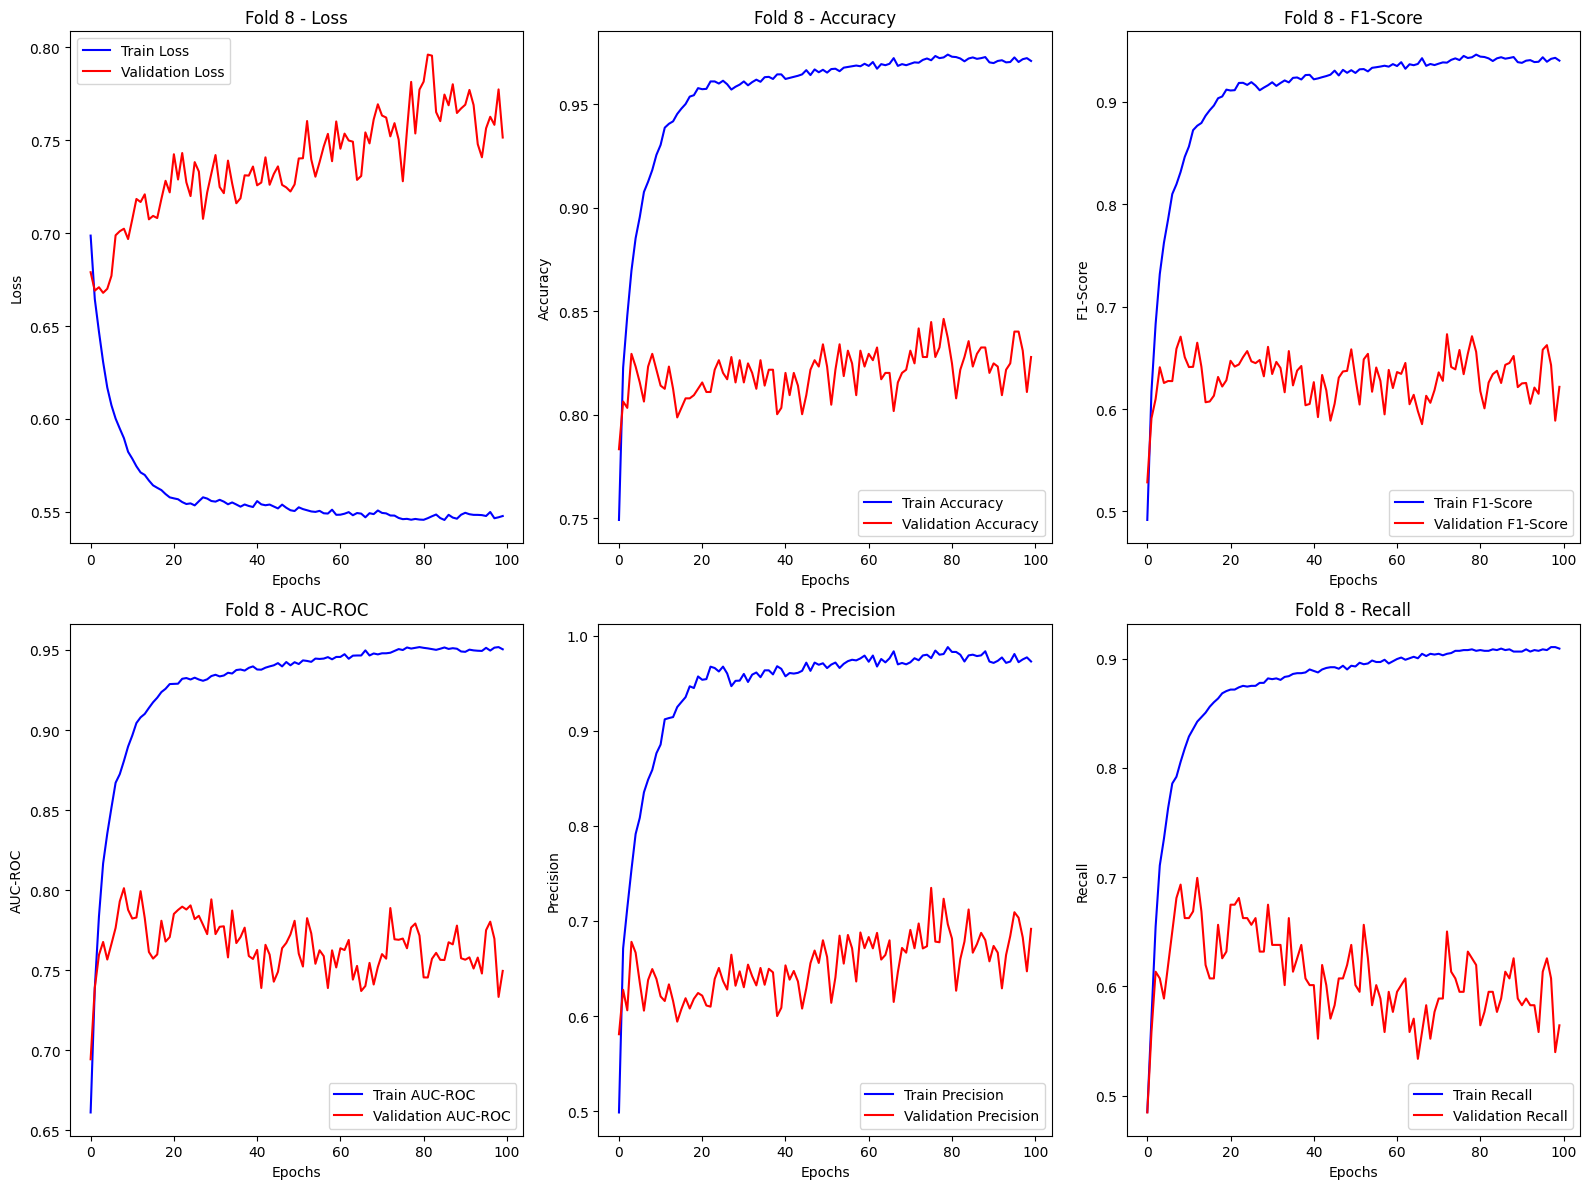

Epoch [10/100], Train Loss: 0.5756, Validation Loss: 0.6726, Validation Accuracy: 0.8372
Epoch [20/100], Train Loss: 0.5590, Validation Loss: 0.6932, Validation Accuracy: 0.8372
Epoch [30/100], Train Loss: 0.5535, Validation Loss: 0.7322, Validation Accuracy: 0.8111
Epoch [40/100], Train Loss: 0.5504, Validation Loss: 0.7294, Validation Accuracy: 0.8157
Epoch [50/100], Train Loss: 0.5494, Validation Loss: 0.7463, Validation Accuracy: 0.8141
Epoch [60/100], Train Loss: 0.5455, Validation Loss: 0.7178, Validation Accuracy: 0.8356
Epoch [70/100], Train Loss: 0.5476, Validation Loss: 0.7572, Validation Accuracy: 0.8249
Epoch [80/100], Train Loss: 0.5498, Validation Loss: 0.7313, Validation Accuracy: 0.8187
Epoch [90/100], Train Loss: 0.5437, Validation Loss: 0.7199, Validation Accuracy: 0.8372
Epoch [100/100], Train Loss: 0.5452, Validation Loss: 0.7383, Validation Accuracy: 0.8433


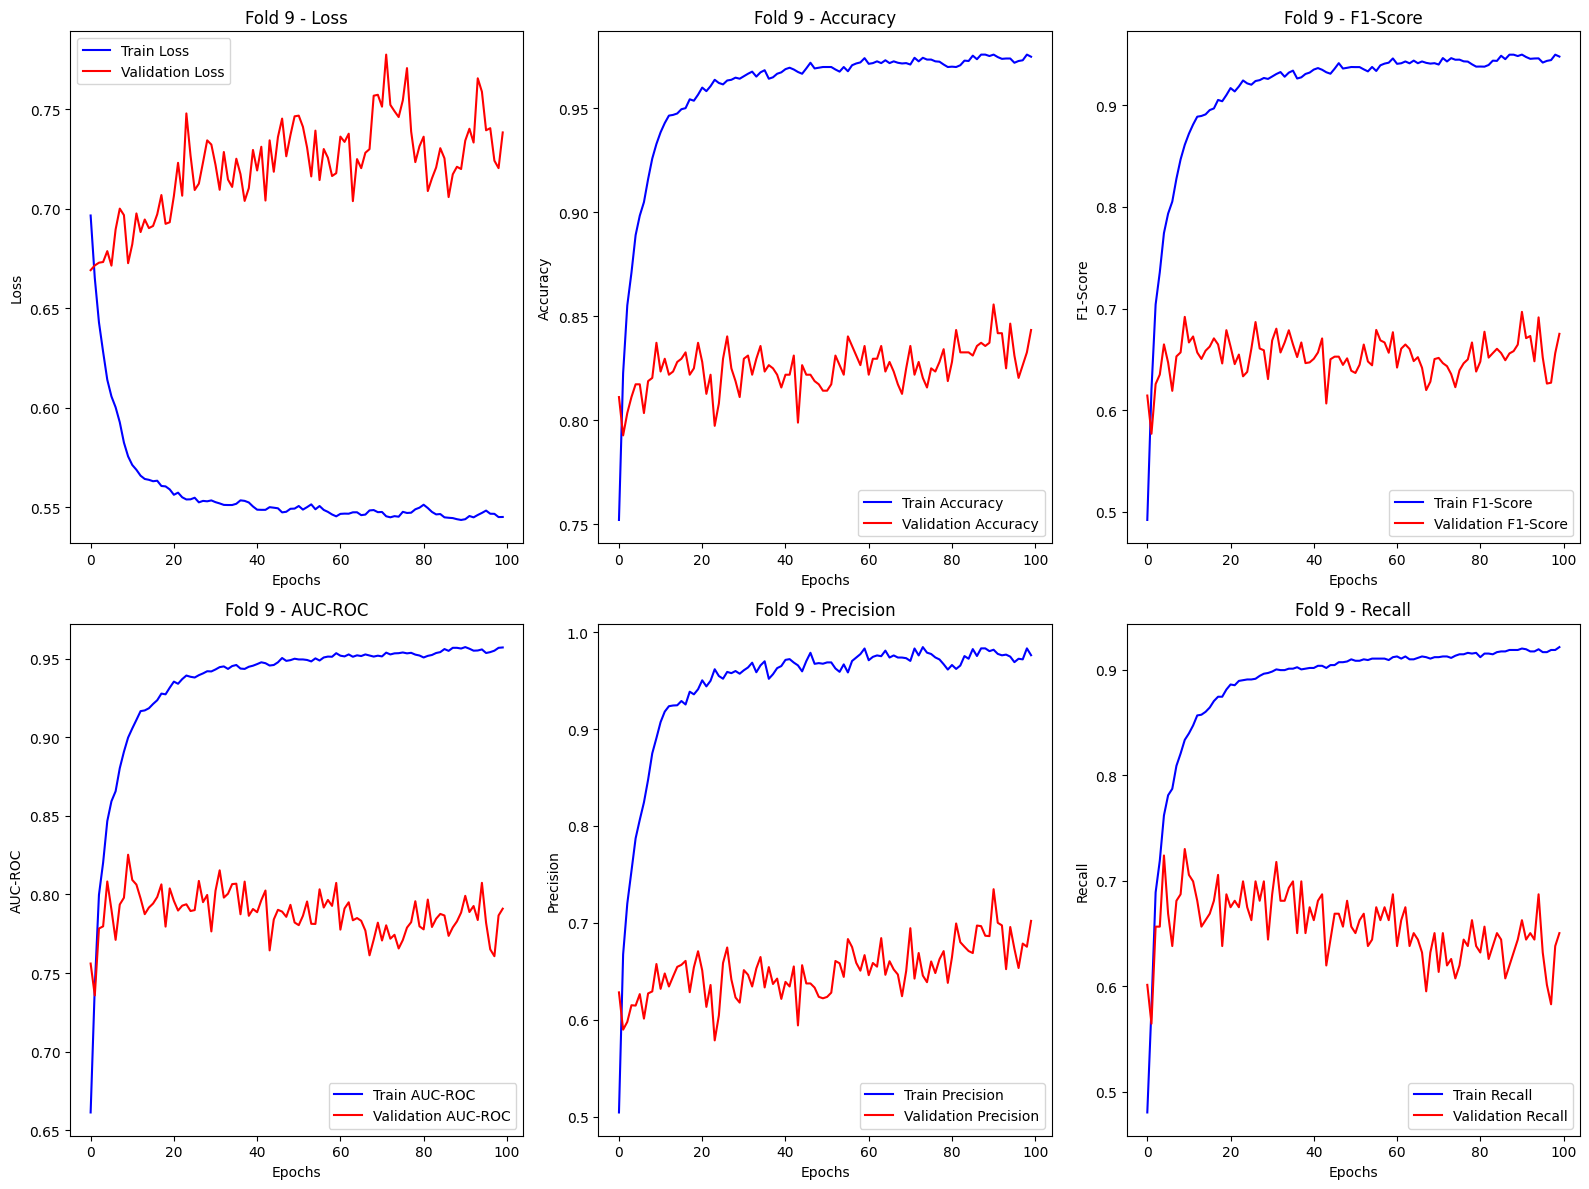

Epoch [10/100], Train Loss: 0.5797, Validation Loss: 0.6912, Validation Accuracy: 0.8187
Epoch [20/100], Train Loss: 0.5574, Validation Loss: 0.7194, Validation Accuracy: 0.8233
Epoch [30/100], Train Loss: 0.5510, Validation Loss: 0.7431, Validation Accuracy: 0.8249
Epoch [40/100], Train Loss: 0.5526, Validation Loss: 0.7633, Validation Accuracy: 0.8218
Epoch [50/100], Train Loss: 0.5516, Validation Loss: 0.7406, Validation Accuracy: 0.8264
Epoch [60/100], Train Loss: 0.5460, Validation Loss: 0.7411, Validation Accuracy: 0.8479
Epoch [70/100], Train Loss: 0.5510, Validation Loss: 0.7279, Validation Accuracy: 0.8510
Epoch [80/100], Train Loss: 0.5459, Validation Loss: 0.7598, Validation Accuracy: 0.8249
Epoch [90/100], Train Loss: 0.5480, Validation Loss: 0.7720, Validation Accuracy: 0.8326
Epoch [100/100], Train Loss: 0.5483, Validation Loss: 0.7604, Validation Accuracy: 0.8126


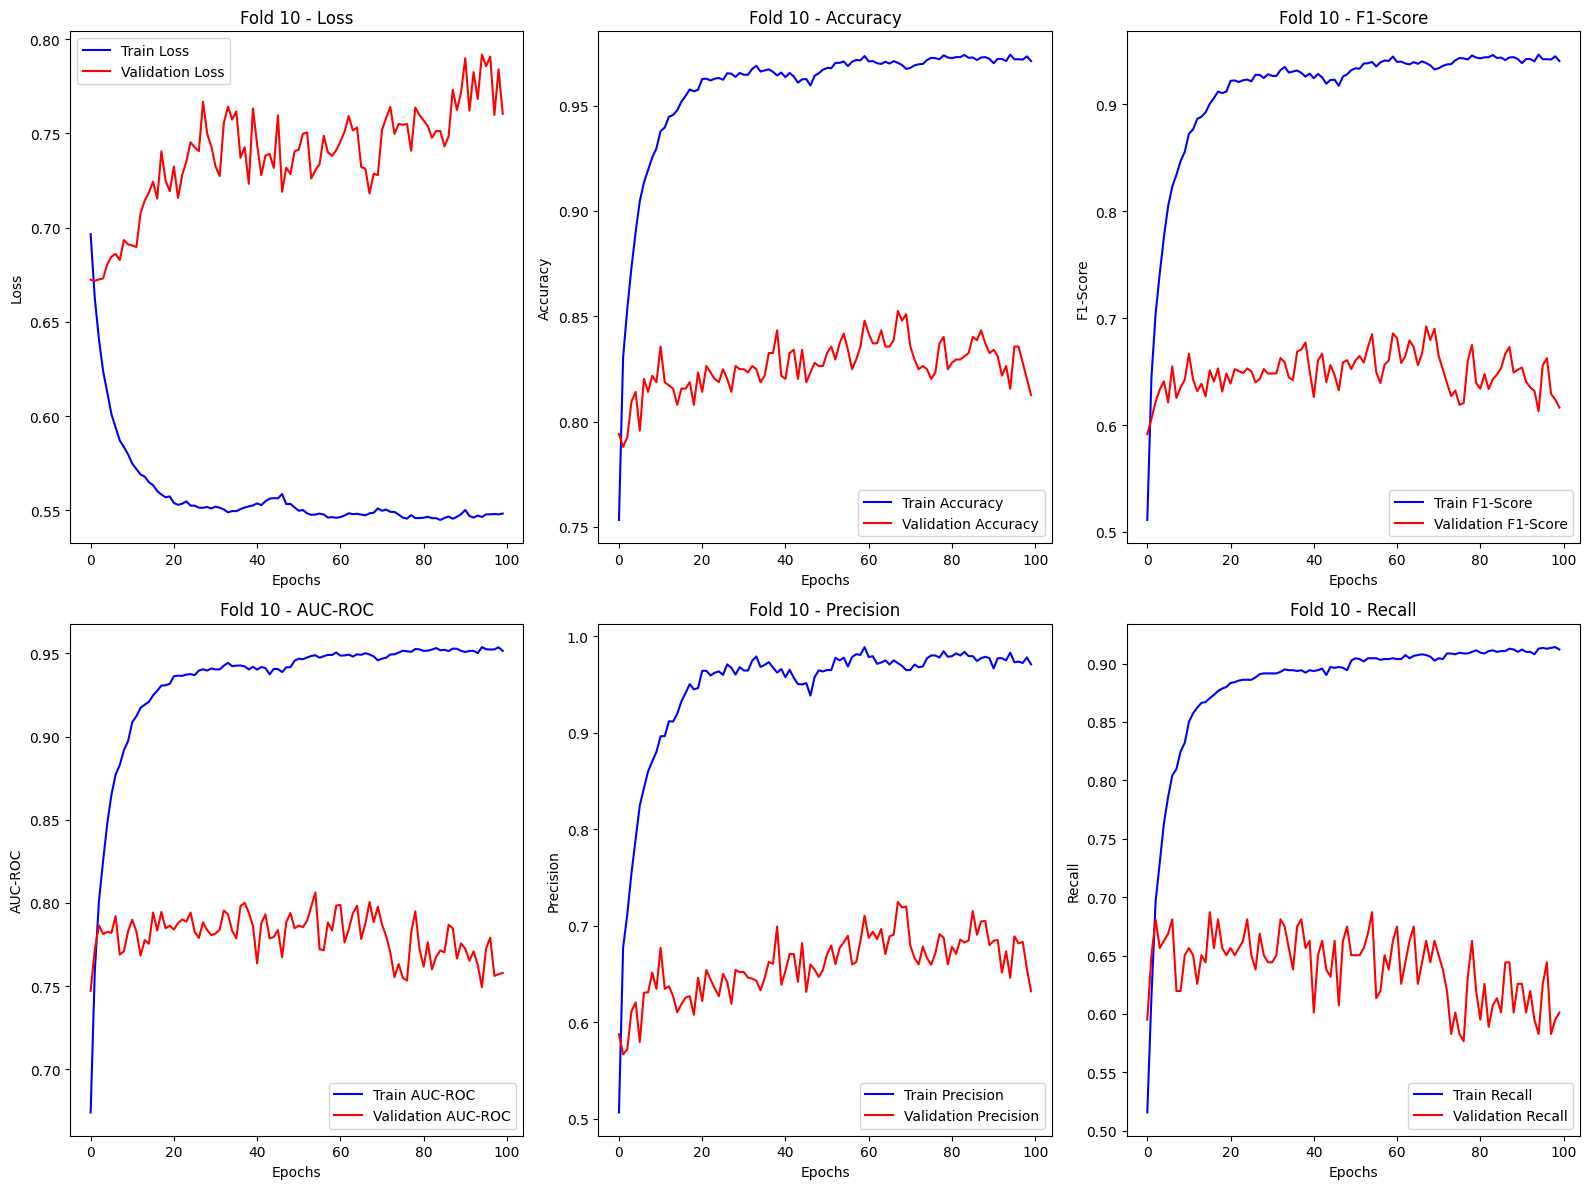

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

# 모델 학습 함수 정의 (수정된 부분 포함)
def train_model(model, final_embeddings, labels, X_val, y_val, epochs=100, batch_size=64):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    # 성능 추적을 위한 리스트
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    f1_train, f1_val = [], []
    auc_roc_train, auc_roc_val = [], []
    precision_train, precision_val = [], []
    recall_train, recall_val = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        correct_train = 0
        total_train = 0
        all_preds_train = []
        all_labels_train = []
        
        for i in range(0, len(final_embeddings), batch_size):
            batch_x = torch.tensor(final_embeddings[i:i + batch_size], dtype=torch.float32).to(device)
            batch_y = torch.tensor(labels[i:i + batch_size], dtype=torch.float32).to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y.view(-1, 1))
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()

            # Train accuracy 계산
            preds_train = torch.sigmoid(outputs).detach().cpu().numpy()
            preds_train_binary = (preds_train > 0.5).astype(int)
            correct_train += (preds_train_binary.flatten() == batch_y.cpu().numpy()).sum()
            total_train += len(batch_y)

            # F1, Precision, Recall 계산
            all_preds_train.extend(preds_train_binary.flatten())
            all_labels_train.extend(batch_y.cpu().numpy())

        # 성능 지표 계산
        train_losses.append(epoch_train_loss / (len(final_embeddings) // batch_size))
        train_accuracies.append(correct_train / total_train)

        f1_train.append(f1_score(all_labels_train, all_preds_train))
        precision_train.append(precision_score(all_labels_train, all_preds_train))
        recall_train.append(recall_score(all_labels_train, all_preds_train))
        auc_roc_train.append(roc_auc_score(all_labels_train, all_preds_train))

        # Validation step
        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.tensor(X_val, dtype=torch.float32).to(device))
            val_loss = criterion(val_outputs, torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device))
            val_losses.append(val_loss.item())

            # Validation accuracy 계산
            val_preds = torch.sigmoid(val_outputs).detach().cpu().numpy()
            val_preds_binary = (val_preds > 0.5).astype(int)
            correct_val = (val_preds_binary.flatten() == y_val).sum()
            val_accuracy = correct_val / len(y_val)
            val_accuracies.append(val_accuracy)

            # Validation F1, Precision, Recall, AUC-ROC 계산
            f1_val.append(f1_score(y_val, val_preds_binary))
            precision_val.append(precision_score(y_val, val_preds_binary))
            recall_val.append(recall_score(y_val, val_preds_binary))
            auc_roc_val.append(roc_auc_score(y_val, val_preds))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")

    return (train_losses, val_losses, train_accuracies, val_accuracies,
            f1_train, f1_val, auc_roc_train, auc_roc_val, precision_train, precision_val, recall_train, recall_val)


# 성능 시각화 (각 fold마다 다른 그래프에 표시)
train_losses_list = []
val_losses_list = []
train_accuracies_list = []
val_accuracies_list = []
f1_train_list = []
f1_val_list = []
auc_roc_train_list = []
auc_roc_val_list = []
precision_train_list = []
precision_val_list = []
recall_train_list = []
recall_val_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 각 fold마다 시드 고정 (필요 시)
    seed_everything(seed)
    
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # RNN 모델 초기화
    rnn_model = RNNModel(input_dim=X.shape[1], hidden_dim=128, output_dim=1)

    # 모델 학습
    (train_losses, val_losses, train_accuracies, val_accuracies,
     f1_train, f1_val, auc_roc_train, auc_roc_val, precision_train, precision_val, recall_train, recall_val) = train_model(
         rnn_model, X_fold_train, y_fold_train, X_fold_val, y_fold_val)

    # 각 fold에 대한 성능 결과 저장
    train_losses_list.append(train_losses)
    val_losses_list.append(val_losses)
    train_accuracies_list.append(train_accuracies)
    val_accuracies_list.append(val_accuracies)
    f1_train_list.append(f1_train)
    f1_val_list.append(f1_val)
    auc_roc_train_list.append(auc_roc_train)
    auc_roc_val_list.append(auc_roc_val)
    precision_train_list.append(precision_train)
    precision_val_list.append(precision_val)
    recall_train_list.append(recall_train)
    recall_val_list.append(recall_val)

    # 각 fold마다 그래프 그리기
    plt.figure(figsize=(16, 12))

    # Loss 그래프
    plt.subplot(2, 3, 1)
    plt.plot(train_losses, label="Train Loss", color='blue')
    plt.plot(val_losses, label="Validation Loss", color='red')
    plt.title(f"Fold {fold + 1} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy 그래프
    plt.subplot(2, 3, 2)
    plt.plot(train_accuracies, label="Train Accuracy", color='blue')
    plt.plot(val_accuracies, label="Validation Accuracy", color='red')
    plt.title(f"Fold {fold + 1} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # F1-Score 그래프
    plt.subplot(2, 3, 3)
    plt.plot(f1_train, label="Train F1-Score", color='blue')
    plt.plot(f1_val, label="Validation F1-Score", color='red')
    plt.title(f"Fold {fold + 1} - F1-Score")
    plt.xlabel("Epochs")
    plt.ylabel("F1-Score")
    plt.legend()

    # AUC-ROC 그래프
    plt.subplot(2, 3, 4)
    plt.plot(auc_roc_train, label="Train AUC-ROC", color='blue')
    plt.plot(auc_roc_val, label="Validation AUC-ROC", color='red')
    plt.title(f"Fold {fold + 1} - AUC-ROC")
    plt.xlabel("Epochs")
    plt.ylabel("AUC-ROC")
    plt.legend()

    # Precision 그래프
    plt.subplot(2, 3, 5)
    plt.plot(precision_train, label="Train Precision", color='blue')
    plt.plot(precision_val, label="Validation Precision", color='red')
    plt.title(f"Fold {fold + 1} - Precision")
    plt.xlabel("Epochs")
    plt.ylabel("Precision")
    plt.legend()

    # Recall 그래프
    plt.subplot(2, 3, 6)
    plt.plot(recall_train, label="Train Recall", color='blue')
    plt.plot(recall_val, label="Validation Recall", color='red')
    plt.title(f"Fold {fold + 1} - Recall")
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()

    # 그래프 표시
    plt.tight_layout()
    plt.show()

LSTM

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

# 모델 학습 함수 정의 (수정된 부분 포함)
def train_model(model, final_embeddings, labels, X_val, y_val, epochs=15, batch_size=64):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    # 성능 추적을 위한 리스트
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    f1_train, f1_val = [], []
    auc_roc_train, auc_roc_val = [], []
    precision_train, precision_val = [], []
    recall_train, recall_val = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        correct_train = 0
        total_train = 0
        all_preds_train = []
        all_labels_train = []
        
        for i in range(0, len(final_embeddings), batch_size):
            batch_x = torch.tensor(final_embeddings[i:i + batch_size], dtype=torch.float32).to(device)
            batch_y = torch.tensor(labels[i:i + batch_size], dtype=torch.float32).to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y.view(-1, 1))
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()

            # Train accuracy 계산
            preds_train = torch.sigmoid(outputs).detach().cpu().numpy()
            preds_train_binary = (preds_train > 0.5).astype(int)
            correct_train += (preds_train_binary.flatten() == batch_y.cpu().numpy()).sum()
            total_train += len(batch_y)

            # F1, Precision, Recall 계산
            all_preds_train.extend(preds_train_binary.flatten())
            all_labels_train.extend(batch_y.cpu().numpy())

        # 성능 지표 계산
        train_losses.append(epoch_train_loss / (len(final_embeddings) // batch_size))
        train_accuracies.append(correct_train / total_train)

        f1_train.append(f1_score(all_labels_train, all_preds_train))
        precision_train.append(precision_score(all_labels_train, all_preds_train))
        recall_train.append(recall_score(all_labels_train, all_preds_train))
        auc_roc_train.append(roc_auc_score(all_labels_train, all_preds_train))

        # Validation step
        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.tensor(X_val, dtype=torch.float32).to(device))
            val_loss = criterion(val_outputs, torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device))
            val_losses.append(val_loss.item())

            # Validation accuracy 계산
            val_preds = torch.sigmoid(val_outputs).detach().cpu().numpy()
            val_preds_binary = (val_preds > 0.5).astype(int)
            correct_val = (val_preds_binary.flatten() == y_val).sum()
            val_accuracy = correct_val / len(y_val)
            val_accuracies.append(val_accuracy)

            # Validation F1, Precision, Recall, AUC-ROC 계산
            f1_val.append(f1_score(y_val, val_preds_binary))
            precision_val.append(precision_score(y_val, val_preds_binary))
            recall_val.append(recall_score(y_val, val_preds_binary))
            auc_roc_val.append(roc_auc_score(y_val, val_preds))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")

    return (train_losses, val_losses, train_accuracies, val_accuracies,
            f1_train, f1_val, auc_roc_train, auc_roc_val, precision_train, precision_val, recall_train, recall_val)


In [11]:
# LSTM 모델 학습 반복문
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 각 fold마다 시드 고정
    seed_everything(seed)
    
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # LSTM 모델 초기화
    lstm_model = LSTMModel(input_dim=X.shape[1], hidden_dim=128, output_dim=1)

    # 모델 학습
    train_model(lstm_model, X_fold_train, y_fold_train, X_fold_val, y_fold_val)

    # Train 성능 평가
    lstm_train_report, lstm_train_auc, lstm_train_specificity = evaluate_model(lstm_model, X_fold_train, y_fold_train)
    
    # Validation 성능 평가
    lstm_val_report, lstm_val_auc, lstm_val_specificity = evaluate_model(lstm_model, X_fold_val, y_fold_val)
    
    # Train 성능 결과 저장
    train_row = pd.DataFrame({
        'Model': ['LSTM'],
        'Fold': [fold + 1],
        'Dataset': ['Train'],
        'Accuracy': [lstm_train_report['accuracy']],
        'F1-Score': [lstm_train_report['1']['f1-score']],
        'Precision': [lstm_train_report['1']['precision']],
        'Recall': [lstm_train_report['1']['recall']],
        'AUC-ROC': [lstm_train_auc],
        'Specificity': [lstm_train_specificity]
    })
    performance_df = pd.concat([performance_df, train_row], ignore_index=True)
    
    # Validation 성능 결과 저장
    val_row = pd.DataFrame({
        'Model': ['LSTM'],
        'Fold': [fold + 1],
        'Dataset': ['Validation'],
        'Accuracy': [lstm_val_report['accuracy']],
        'F1-Score': [lstm_val_report['1']['f1-score']],
        'Precision': [lstm_val_report['1']['precision']],
        'Recall': [lstm_val_report['1']['recall']],
        'AUC-ROC': [lstm_val_auc],
        'Specificity': [lstm_val_specificity]
    })
    performance_df_val = pd.concat([performance_df_val, val_row], ignore_index=True)

# 성능 데이터프레임 출력
performance_df

Epoch [10/15], Train Loss: 0.0027, Validation Loss: 0.4450, Validation Accuracy: 0.8543
Epoch [10/15], Train Loss: 0.0029, Validation Loss: 0.4283, Validation Accuracy: 0.8405
Epoch [10/15], Train Loss: 0.0027, Validation Loss: 0.4349, Validation Accuracy: 0.8420
Epoch [10/15], Train Loss: 0.0027, Validation Loss: 0.4340, Validation Accuracy: 0.8482
Epoch [10/15], Train Loss: 0.0027, Validation Loss: 0.5301, Validation Accuracy: 0.8218
Epoch [10/15], Train Loss: 0.0028, Validation Loss: 0.4121, Validation Accuracy: 0.8602
Epoch [10/15], Train Loss: 0.0029, Validation Loss: 0.3765, Validation Accuracy: 0.8756
Epoch [10/15], Train Loss: 0.0027, Validation Loss: 0.3756, Validation Accuracy: 0.8740
Epoch [10/15], Train Loss: 0.0030, Validation Loss: 0.3254, Validation Accuracy: 0.8879
Epoch [10/15], Train Loss: 0.0027, Validation Loss: 0.4211, Validation Accuracy: 0.8541


,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,RNN,1,Train,0.911634,0.833761,0.787273,0.886085,0.937725,0.920155
1,RNN,2,Train,0.915728,0.840542,0.797794,0.888131,0.939152,0.924932
2,RNN,3,Train,0.920846,0.848663,0.813125,0.887449,0.939248,0.931984
3,RNN,4,Train,0.913852,0.837464,0.792809,0.887449,0.938749,0.922657
4,RNN,5,Train,0.916937,0.842446,0.801724,0.887526,0.939116,0.926752
5,RNN,6,Train,0.913696,0.836774,0.793758,0.884720,0.937111,0.923357
6,RNN,7,Train,0.919325,0.846179,0.808577,0.887449,0.939049,0.929952
7,RNN,8,Train,0.920177,0.847755,0.810323,0.888813,0.939832,0.930635
8,RNN,9,Train,0.915913,0.838731,0.805783,0.874488,0.932380,0.929725
9,RNN,10,Train,0.911138,0.833493,0.784125,0.889495,0.939330,0.918353


In [42]:
# 성능 데이터프레임 초기화
performance_df = pd.DataFrame(columns=['Model', 'Fold', 'Dataset', 'Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC', 'Specificity'])
performance_df_test = pd.DataFrame(columns=['Model', 'Fold', 'Dataset', 'Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC', 'Specificity'])

# 모델 학습을 위한 데이터
X_train = train_embeddings
y_train = train_labels
X_test = test_embeddings
y_test = test_labels

# 시드 고정
seed_everything(seed)

# LSTM 모델 초기화
lstm_model = LSTMModel(input_dim=X_train.shape[1], hidden_dim=128, output_dim=1)

# 모델 학습
train_model(lstm_model, X_train, y_train, X_test, y_test)

# Train 성능 평가
lstm_train_report, lstm_train_auc, lstm_train_specificity = evaluate_model(lstm_model, X_train, y_train)

# Test 성능 평가
lstm_test_report, lstm_test_auc, lstm_test_specificity = evaluate_model(lstm_model, X_test, y_test)

# Train 성능 결과 저장
train_row = pd.DataFrame({
    'Model': ['LSTM'],
    'Fold': [1],  # fold는 1로 고정
    'Dataset': ['Train'],
    'Accuracy': [lstm_train_report['accuracy']],
    'F1-Score': [lstm_train_report['1']['f1-score']],
    'Precision': [lstm_train_report['1']['precision']],
    'Recall': [lstm_train_report['1']['recall']],
    'AUC-ROC': [lstm_train_auc],
    'Specificity': [lstm_train_specificity]
})
performance_df = pd.concat([performance_df, train_row], ignore_index=True)

# Test 성능 결과 저장
test_row = pd.DataFrame({
    'Model': ['LSTM'],
    'Fold': [1],  # fold는 1로 고정
    'Dataset': ['Test'],
    'Accuracy': [lstm_test_report['accuracy']],
    'F1-Score': [lstm_test_report['1']['f1-score']],
    'Precision': [lstm_test_report['1']['precision']],
    'Recall': [lstm_test_report['1']['recall']],
    'AUC-ROC': [lstm_test_auc],
    'Specificity': [lstm_test_specificity]
})
performance_df_test = pd.concat([performance_df_test, test_row], ignore_index=True)

# 성능 데이터프레임 출력
performance_df

/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/torch/nn/modules/rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch [10/10], Validation Loss: 0.3985


/tmp/ipykernel_58707/159378459.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  performance_df = pd.concat([performance_df, train_row], ignore_index=True)
/tmp/ipykernel_58707/159378459.py:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  performance_df_test = pd.concat([performance_df_test, test_row], ignore_index=True)


,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,LSTM,1,Train,0.8762,0.712182,0.850746,0.612433,0.942097,0.964167


In [43]:
performance_df_test

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,LSTM,1,Test,0.80046,0.527273,0.647321,0.444785,0.85201,0.91914


In [39]:
performance_df_val

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,LSTM,1,Validation,0.842025,0.636042,0.750000,0.552147,0.902255,0.938650
1,LSTM,2,Validation,0.848160,0.645161,0.775862,0.552147,0.905140,0.946830
2,LSTM,3,Validation,0.860429,0.682927,0.790323,0.601227,0.907060,0.946830
3,LSTM,4,Validation,0.844854,0.643110,0.752066,0.561728,0.904958,0.938650
4,LSTM,5,Validation,0.867896,0.715232,0.776978,0.662577,0.904154,0.936475
5,LSTM,6,Validation,0.827957,0.619048,0.694656,0.558282,0.874195,0.918033
6,LSTM,7,Validation,0.849462,0.659722,0.760000,0.582822,0.891255,0.938525
7,LSTM,8,Validation,0.838710,0.623656,0.750000,0.533742,0.893920,0.940574
8,LSTM,9,Validation,0.857143,0.656827,0.824074,0.546012,0.899980,0.961066
9,LSTM,10,Validation,0.852535,0.666667,0.768000,0.588957,0.897855,0.940574


In [13]:
import torch
print(torch.cuda.current_device())  # 현재 사용 중인 GPU ID 출력

0


In [14]:
import torch
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

GPU 0: NVIDIA GeForce RTX 3070


Epoch [10/20], Train Loss: 0.0031, Validation Loss: 0.4216, Validation Accuracy: 0.8596
Epoch [20/20], Train Loss: 0.0007, Validation Loss: 0.4717, Validation Accuracy: 0.8588


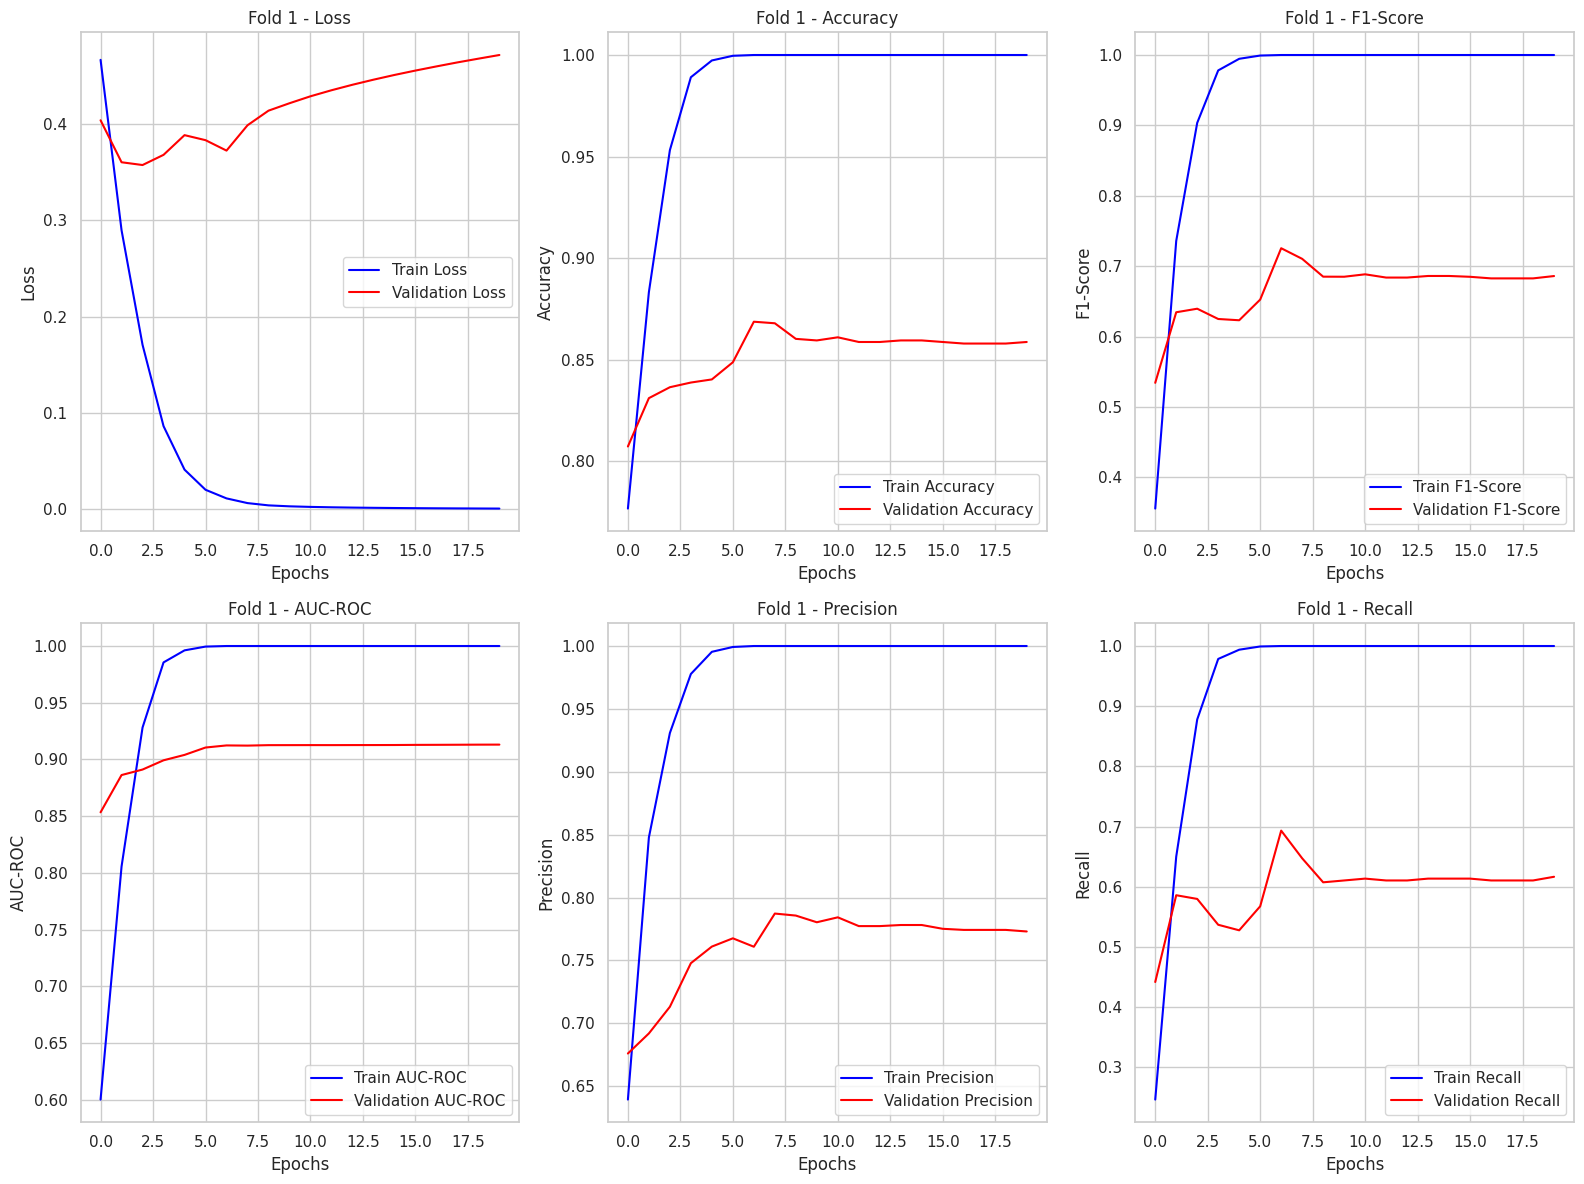

Epoch [10/20], Train Loss: 0.0032, Validation Loss: 0.3850, Validation Accuracy: 0.8695
Epoch [20/20], Train Loss: 0.0008, Validation Loss: 0.4220, Validation Accuracy: 0.8718


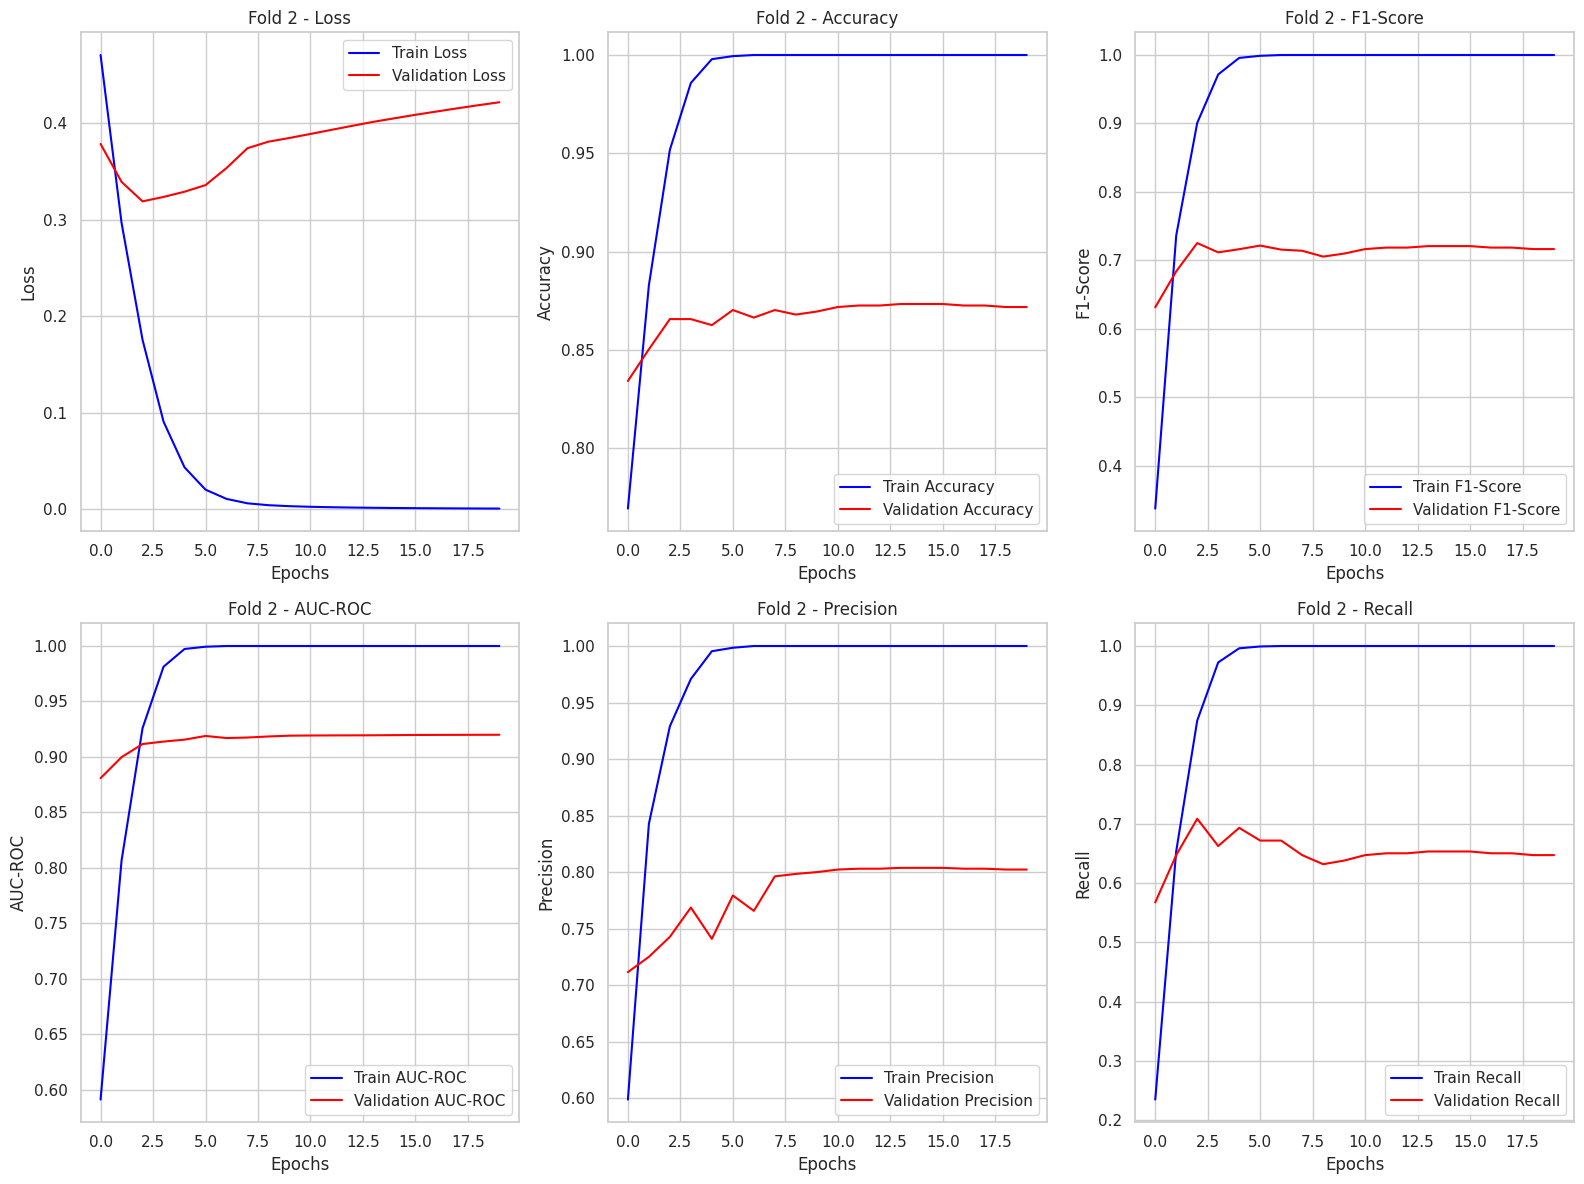

Epoch [10/20], Train Loss: 0.0032, Validation Loss: 0.4015, Validation Accuracy: 0.8519
Epoch [20/20], Train Loss: 0.0007, Validation Loss: 0.4443, Validation Accuracy: 0.8550


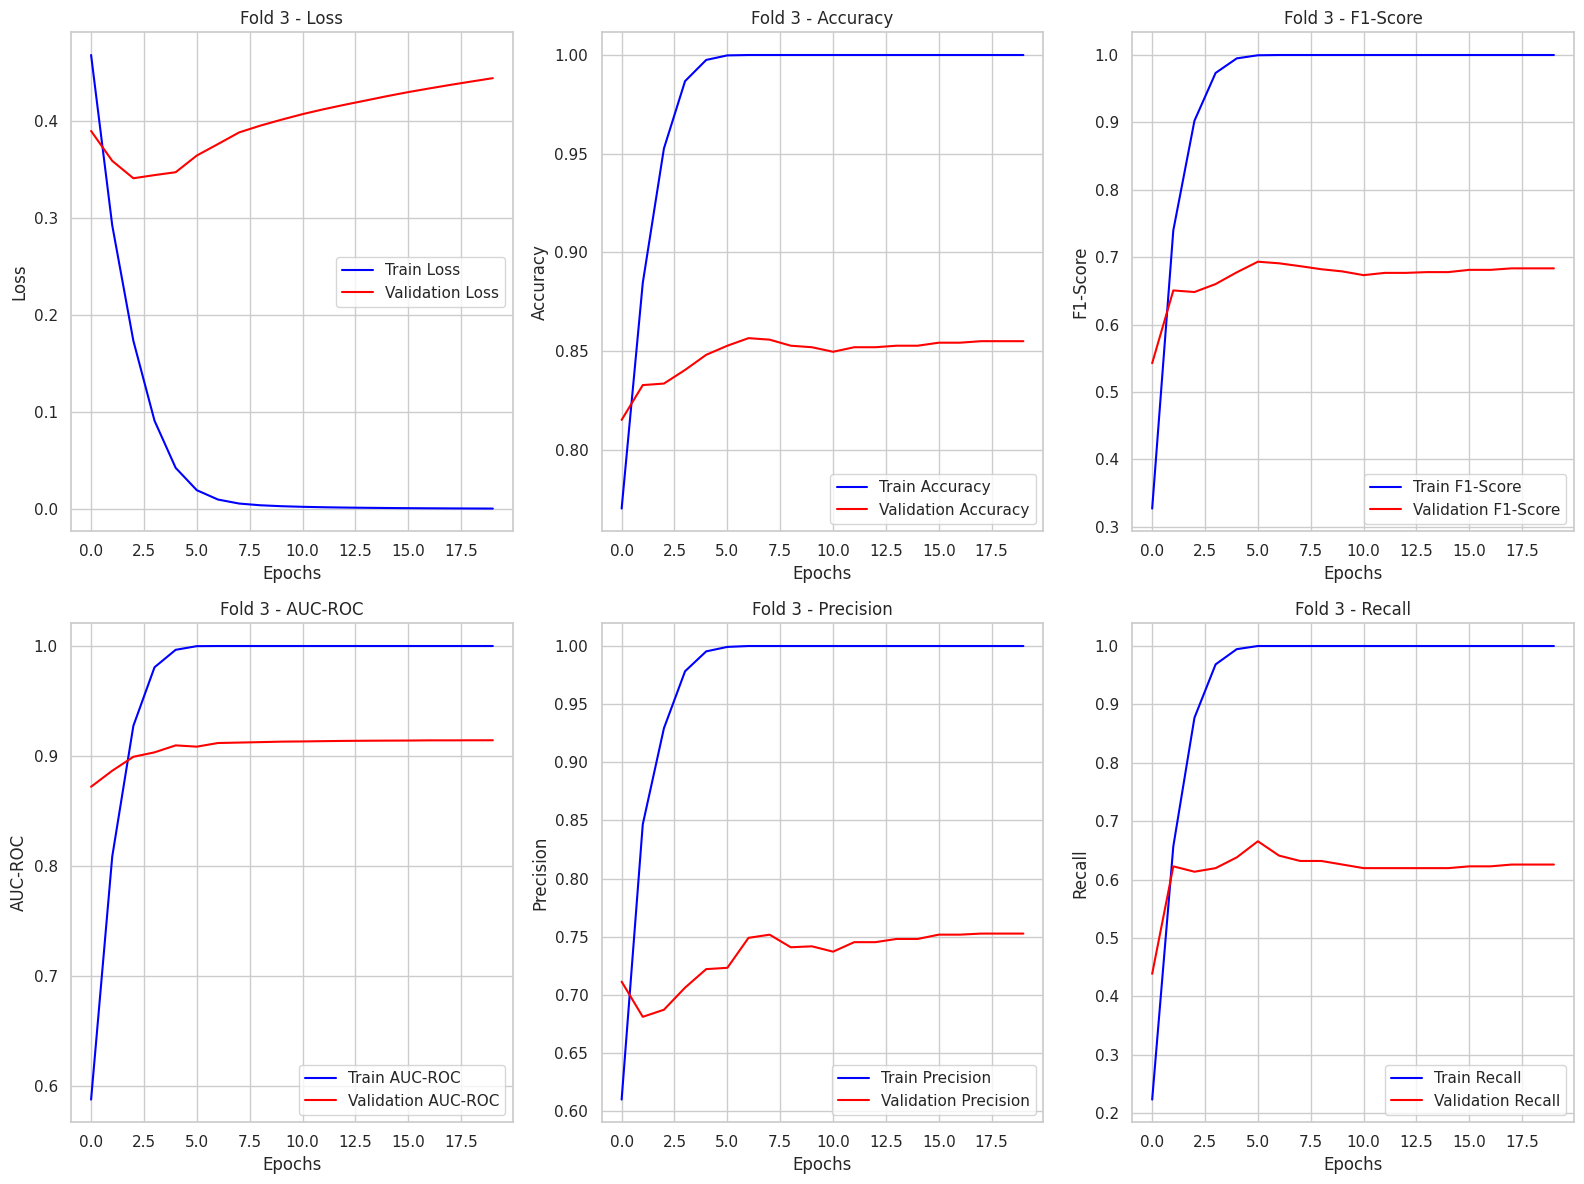

Epoch [10/20], Train Loss: 0.0032, Validation Loss: 0.4337, Validation Accuracy: 0.8411
Epoch [20/20], Train Loss: 0.0007, Validation Loss: 0.4844, Validation Accuracy: 0.8388


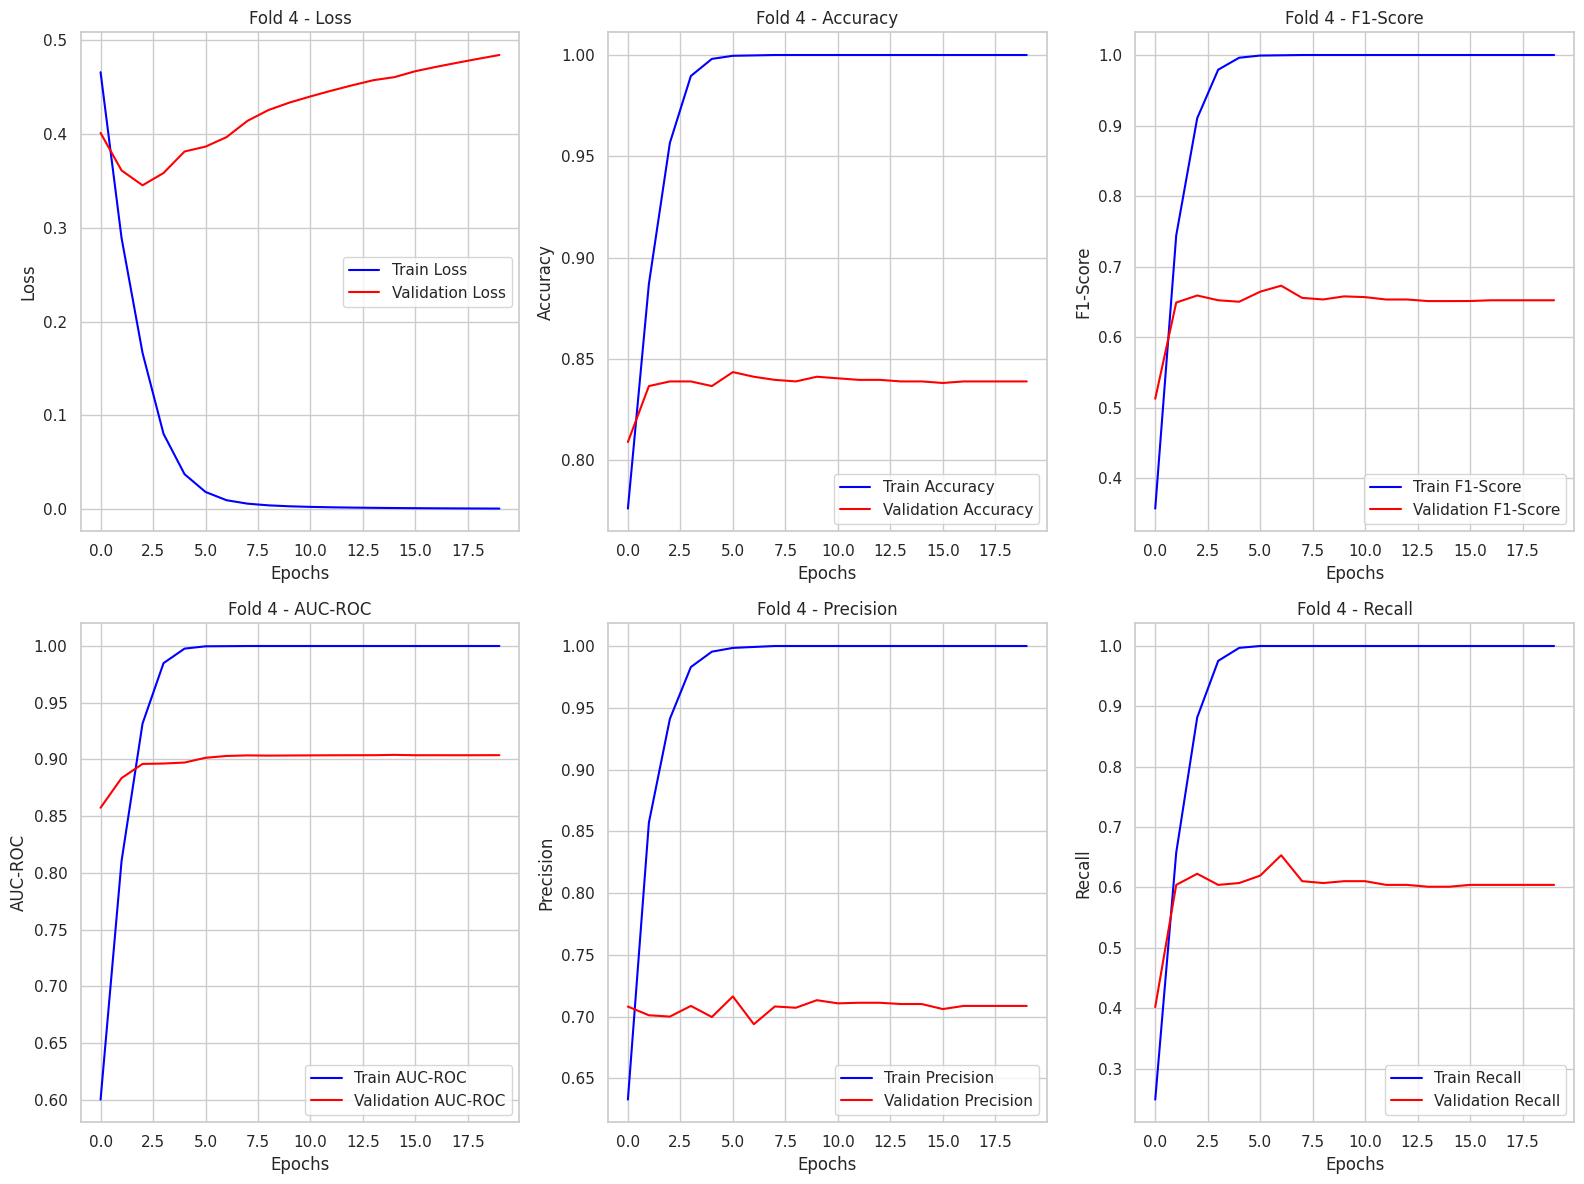

Epoch [10/20], Train Loss: 0.0033, Validation Loss: 0.4083, Validation Accuracy: 0.8579
Epoch [20/20], Train Loss: 0.0008, Validation Loss: 0.4479, Validation Accuracy: 0.8610


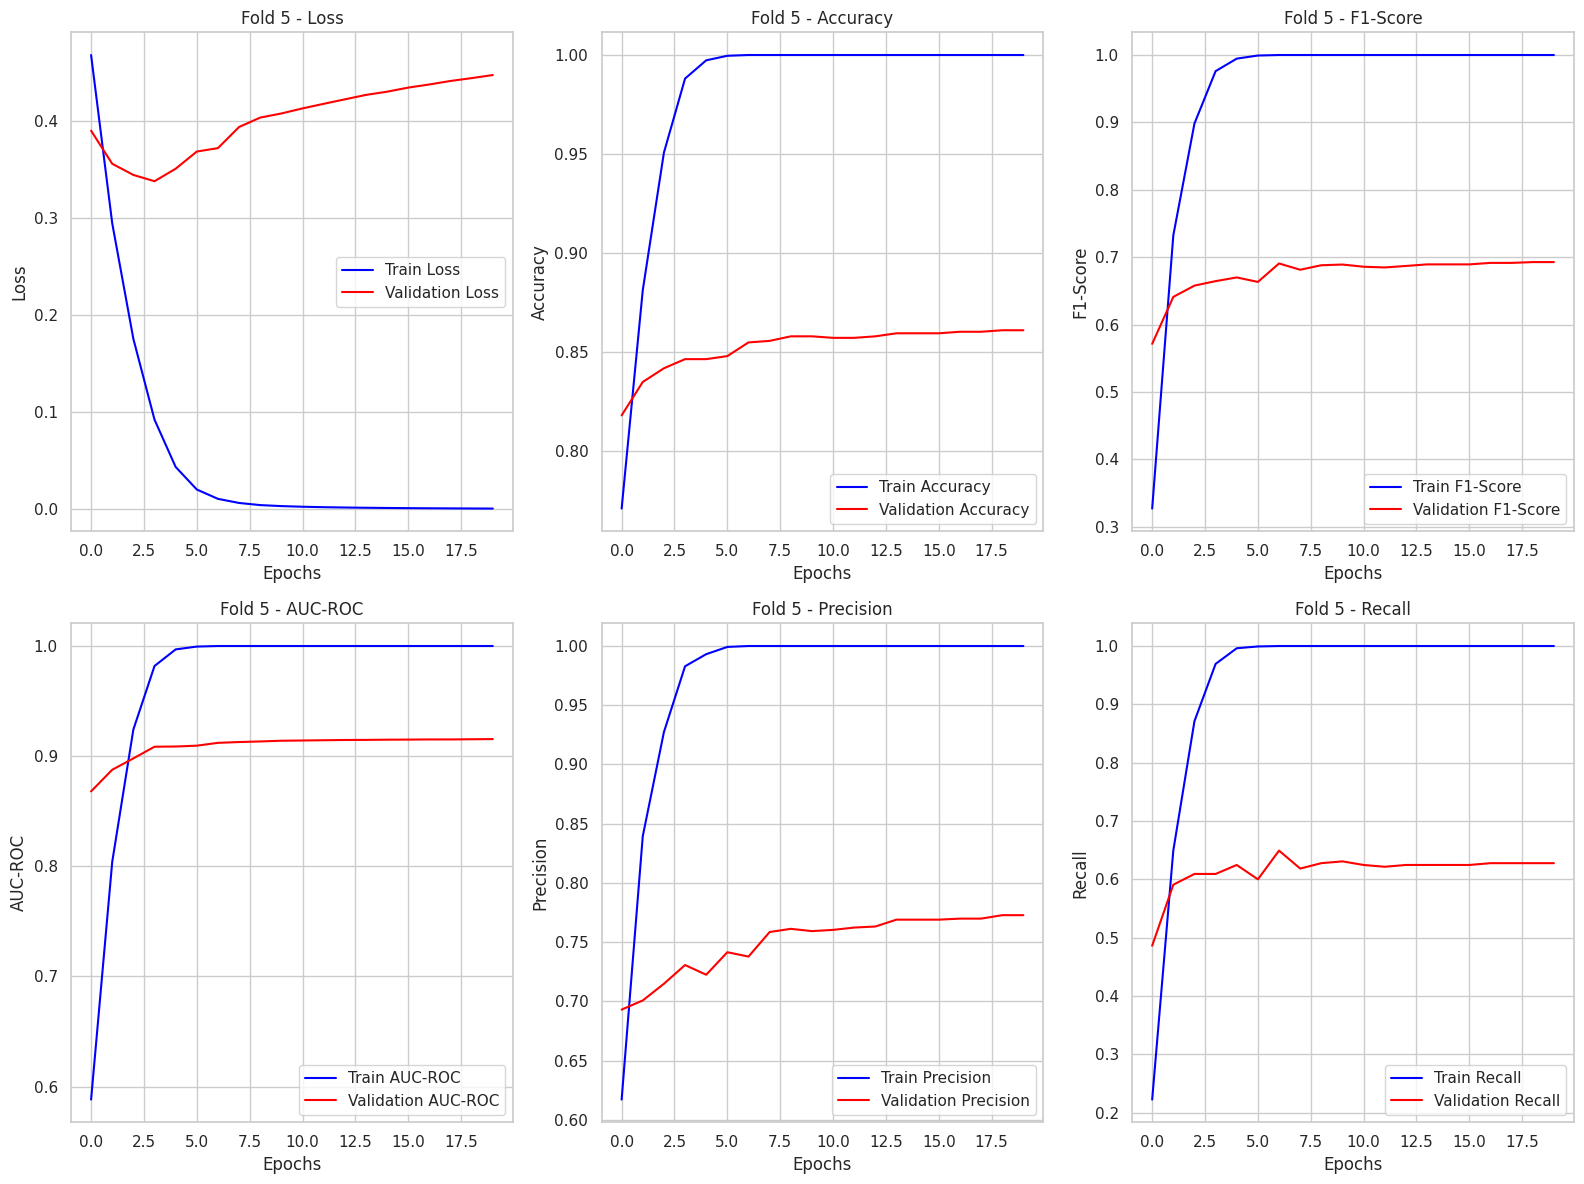

In [302]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

# 모델 학습 함수 정의 (수정된 부분 포함)
def train_model(model, final_embeddings, labels, X_val, y_val, epochs=20, batch_size=64):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    # 성능 추적을 위한 리스트
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    f1_train, f1_val = [], []
    auc_roc_train, auc_roc_val = [], []
    precision_train, precision_val = [], []
    recall_train, recall_val = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        correct_train = 0
        total_train = 0
        all_preds_train = []
        all_labels_train = []
        
        for i in range(0, len(final_embeddings), batch_size):
            batch_x = torch.tensor(final_embeddings[i:i + batch_size], dtype=torch.float32).to(device)
            batch_y = torch.tensor(labels[i:i + batch_size], dtype=torch.float32).to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y.view(-1, 1))
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()

            # Train accuracy 계산
            preds_train = torch.sigmoid(outputs).detach().cpu().numpy()
            preds_train_binary = (preds_train > 0.5).astype(int)
            correct_train += (preds_train_binary.flatten() == batch_y.cpu().numpy()).sum()
            total_train += len(batch_y)

            # F1, Precision, Recall 계산
            all_preds_train.extend(preds_train_binary.flatten())
            all_labels_train.extend(batch_y.cpu().numpy())

        # 성능 지표 계산
        train_losses.append(epoch_train_loss / (len(final_embeddings) // batch_size))
        train_accuracies.append(correct_train / total_train)

        f1_train.append(f1_score(all_labels_train, all_preds_train))
        precision_train.append(precision_score(all_labels_train, all_preds_train))
        recall_train.append(recall_score(all_labels_train, all_preds_train))
        auc_roc_train.append(roc_auc_score(all_labels_train, all_preds_train))

        # Validation step
        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.tensor(X_val, dtype=torch.float32).to(device))
            val_loss = criterion(val_outputs, torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device))
            val_losses.append(val_loss.item())

            # Validation accuracy 계산
            val_preds = torch.sigmoid(val_outputs).detach().cpu().numpy()
            val_preds_binary = (val_preds > 0.5).astype(int)
            correct_val = (val_preds_binary.flatten() == y_val).sum()
            val_accuracy = correct_val / len(y_val)
            val_accuracies.append(val_accuracy)

            # Validation F1, Precision, Recall, AUC-ROC 계산
            f1_val.append(f1_score(y_val, val_preds_binary))
            precision_val.append(precision_score(y_val, val_preds_binary))
            recall_val.append(recall_score(y_val, val_preds_binary))
            auc_roc_val.append(roc_auc_score(y_val, val_preds))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")

    return (train_losses, val_losses, train_accuracies, val_accuracies,
            f1_train, f1_val, auc_roc_train, auc_roc_val, precision_train, precision_val, recall_train, recall_val)


# 성능 시각화 (각 fold마다 다른 그래프에 표시)
train_losses_list = []
val_losses_list = []
train_accuracies_list = []
val_accuracies_list = []
f1_train_list = []
f1_val_list = []
auc_roc_train_list = []
auc_roc_val_list = []
precision_train_list = []
precision_val_list = []
recall_train_list = []
recall_val_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 각 fold마다 시드 고정 (필요 시)
    seed_everything(seed)
    
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # RNN 모델 초기화
    lstm_model = LSTMModel(input_dim=X.shape[1], hidden_dim=128, output_dim=1)

    # 모델 학습
    (train_losses, val_losses, train_accuracies, val_accuracies,
     f1_train, f1_val, auc_roc_train, auc_roc_val, precision_train, precision_val, recall_train, recall_val) = train_model(
         lstm_model, X_fold_train, y_fold_train, X_fold_val, y_fold_val)

    # 각 fold에 대한 성능 결과 저장
    train_losses_list.append(train_losses)
    val_losses_list.append(val_losses)
    train_accuracies_list.append(train_accuracies)
    val_accuracies_list.append(val_accuracies)
    f1_train_list.append(f1_train)
    f1_val_list.append(f1_val)
    auc_roc_train_list.append(auc_roc_train)
    auc_roc_val_list.append(auc_roc_val)
    precision_train_list.append(precision_train)
    precision_val_list.append(precision_val)
    recall_train_list.append(recall_train)
    recall_val_list.append(recall_val)

    # 각 fold마다 그래프 그리기
    plt.figure(figsize=(16, 12))

    # Loss 그래프
    plt.subplot(2, 3, 1)
    plt.plot(train_losses, label="Train Loss", color='blue')
    plt.plot(val_losses, label="Validation Loss", color='red')
    plt.title(f"Fold {fold + 1} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy 그래프
    plt.subplot(2, 3, 2)
    plt.plot(train_accuracies, label="Train Accuracy", color='blue')
    plt.plot(val_accuracies, label="Validation Accuracy", color='red')
    plt.title(f"Fold {fold + 1} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # F1-Score 그래프
    plt.subplot(2, 3, 3)
    plt.plot(f1_train, label="Train F1-Score", color='blue')
    plt.plot(f1_val, label="Validation F1-Score", color='red')
    plt.title(f"Fold {fold + 1} - F1-Score")
    plt.xlabel("Epochs")
    plt.ylabel("F1-Score")
    plt.legend()

    # AUC-ROC 그래프
    plt.subplot(2, 3, 4)
    plt.plot(auc_roc_train, label="Train AUC-ROC", color='blue')
    plt.plot(auc_roc_val, label="Validation AUC-ROC", color='red')
    plt.title(f"Fold {fold + 1} - AUC-ROC")
    plt.xlabel("Epochs")
    plt.ylabel("AUC-ROC")
    plt.legend()

    # Precision 그래프
    plt.subplot(2, 3, 5)
    plt.plot(precision_train, label="Train Precision", color='blue')
    plt.plot(precision_val, label="Validation Precision", color='red')
    plt.title(f"Fold {fold + 1} - Precision")
    plt.xlabel("Epochs")
    plt.ylabel("Precision")
    plt.legend()

    # Recall 그래프
    plt.subplot(2, 3, 6)
    plt.plot(recall_train, label="Train Recall", color='blue')
    plt.plot(recall_val, label="Validation Recall", color='red')
    plt.title(f"Fold {fold + 1} - Recall")
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()

    # 그래프 표시
    plt.tight_layout()
    plt.show()

GRU

In [289]:
# GRU 모델 학습 반복문
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 각 fold마다 시드 고정
    seed_everything(seed)
    
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # GRU 모델 초기화
    gru_model = GRUModel(input_dim=X.shape[1], hidden_dim=128, output_dim=1)

    # 모델 학습
    train_model(gru_model, X_fold_train, y_fold_train, X_fold_val, y_fold_val)

    # Train 성능 평가
    gru_train_report, gru_train_auc, gru_train_specificity = evaluate_model(gru_model, X_fold_train, y_fold_train)
    
    # Validation 성능 평가
    gru_val_report, gru_val_auc, gru_val_specificity = evaluate_model(gru_model, X_fold_val, y_fold_val)
    
    # Train 성능 결과 저장
    train_row = pd.DataFrame({
        'Model': ['GRU'],
        'Fold': [fold + 1],
        'Dataset': ['Train'],
        'Accuracy': [gru_train_report['accuracy']],
        'F1-Score': [gru_train_report['1']['f1-score']],
        'Precision': [gru_train_report['1']['precision']],
        'Recall': [gru_train_report['1']['recall']],
        'AUC-ROC': [gru_train_auc],
        'Specificity': [gru_train_specificity]
    })
    performance_df = pd.concat([performance_df, train_row], ignore_index=True)
    
    # Validation 성능 결과 저장
    val_row = pd.DataFrame({
        'Model': ['GRU'],
        'Fold': [fold + 1],
        'Dataset': ['Validation'],
        'Accuracy': [gru_val_report['accuracy']],
        'F1-Score': [gru_val_report['1']['f1-score']],
        'Precision': [gru_val_report['1']['precision']],
        'Recall': [gru_val_report['1']['recall']],
        'AUC-ROC': [gru_val_auc],
        'Specificity': [gru_val_specificity]
    })
    performance_df_val = pd.concat([performance_df_val, val_row], ignore_index=True)

# 성능 데이터프레임 출력
performance_df

Epoch [10/40], Validation Loss: 0.5033
Epoch [20/40], Validation Loss: 0.5656
Epoch [30/40], Validation Loss: 0.6037
Epoch [40/40], Validation Loss: 0.6355
Epoch [10/40], Validation Loss: 0.4496
Epoch [20/40], Validation Loss: 0.4904
Epoch [30/40], Validation Loss: 0.5200
Epoch [40/40], Validation Loss: 0.5445
Epoch [10/40], Validation Loss: 0.4604
Epoch [20/40], Validation Loss: 0.5149
Epoch [30/40], Validation Loss: 0.5492
Epoch [40/40], Validation Loss: 0.5768
Epoch [10/40], Validation Loss: 0.5388
Epoch [20/40], Validation Loss: 0.5964
Epoch [30/40], Validation Loss: 0.6359
Epoch [40/40], Validation Loss: 0.6683
Epoch [10/40], Validation Loss: 0.4797
Epoch [20/40], Validation Loss: 0.5322
Epoch [30/40], Validation Loss: 0.5677
Epoch [40/40], Validation Loss: 0.5945


,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,RNN,1,Train,0.999616,0.999233,0.999233,0.999233,0.999998,0.999744
1,RNN,2,Train,0.998849,0.997698,0.997698,0.997698,0.999998,0.999232
2,RNN,3,Train,0.999040,0.998081,0.998464,0.997698,0.999996,0.999488
3,RNN,4,Train,0.999232,0.998465,0.998465,0.998465,0.999998,0.999488
4,RNN,5,Train,0.999233,0.998465,0.999232,0.997699,0.999997,0.999744
5,LSTM,1,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,LSTM,2,Train,0.999808,0.999616,1.000000,0.999233,1.000000,1.000000
7,LSTM,3,Train,0.999808,0.999616,1.000000,0.999233,1.000000,1.000000
8,LSTM,4,Train,0.999616,0.999232,1.000000,0.998465,1.000000,1.000000
9,LSTM,5,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [290]:
performance_df_val

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,RNN,1,Validation,0.853415,0.684298,0.741935,0.634969,0.906202,0.926305
1,RNN,2,Validation,0.861090,0.714060,0.736156,0.693252,0.913680,0.917093
2,RNN,3,Validation,0.866462,0.715686,0.765734,0.671779,0.910845,0.931423
3,RNN,4,Validation,0.843438,0.679245,0.696774,0.662577,0.901859,0.903787
4,RNN,5,Validation,0.864823,0.715210,0.754266,0.680000,0.916498,0.926305
5,LSTM,1,Validation,0.859555,0.687179,0.776062,0.616564,0.913539,0.940635
6,LSTM,2,Validation,0.870299,0.713073,0.798479,0.644172,0.920189,0.945752
7,LSTM,3,Validation,0.858787,0.692308,0.761029,0.634969,0.914782,0.933470
8,LSTM,4,Validation,0.838833,0.652318,0.708633,0.604294,0.903341,0.917093
9,LSTM,5,Validation,0.864055,0.701518,0.776119,0.640000,0.916306,0.938588


Epoch [10/20], Train Loss: 0.0044, Validation Loss: 0.5033, Validation Accuracy: 0.8427
Epoch [20/20], Train Loss: 0.0008, Validation Loss: 0.5656, Validation Accuracy: 0.8457


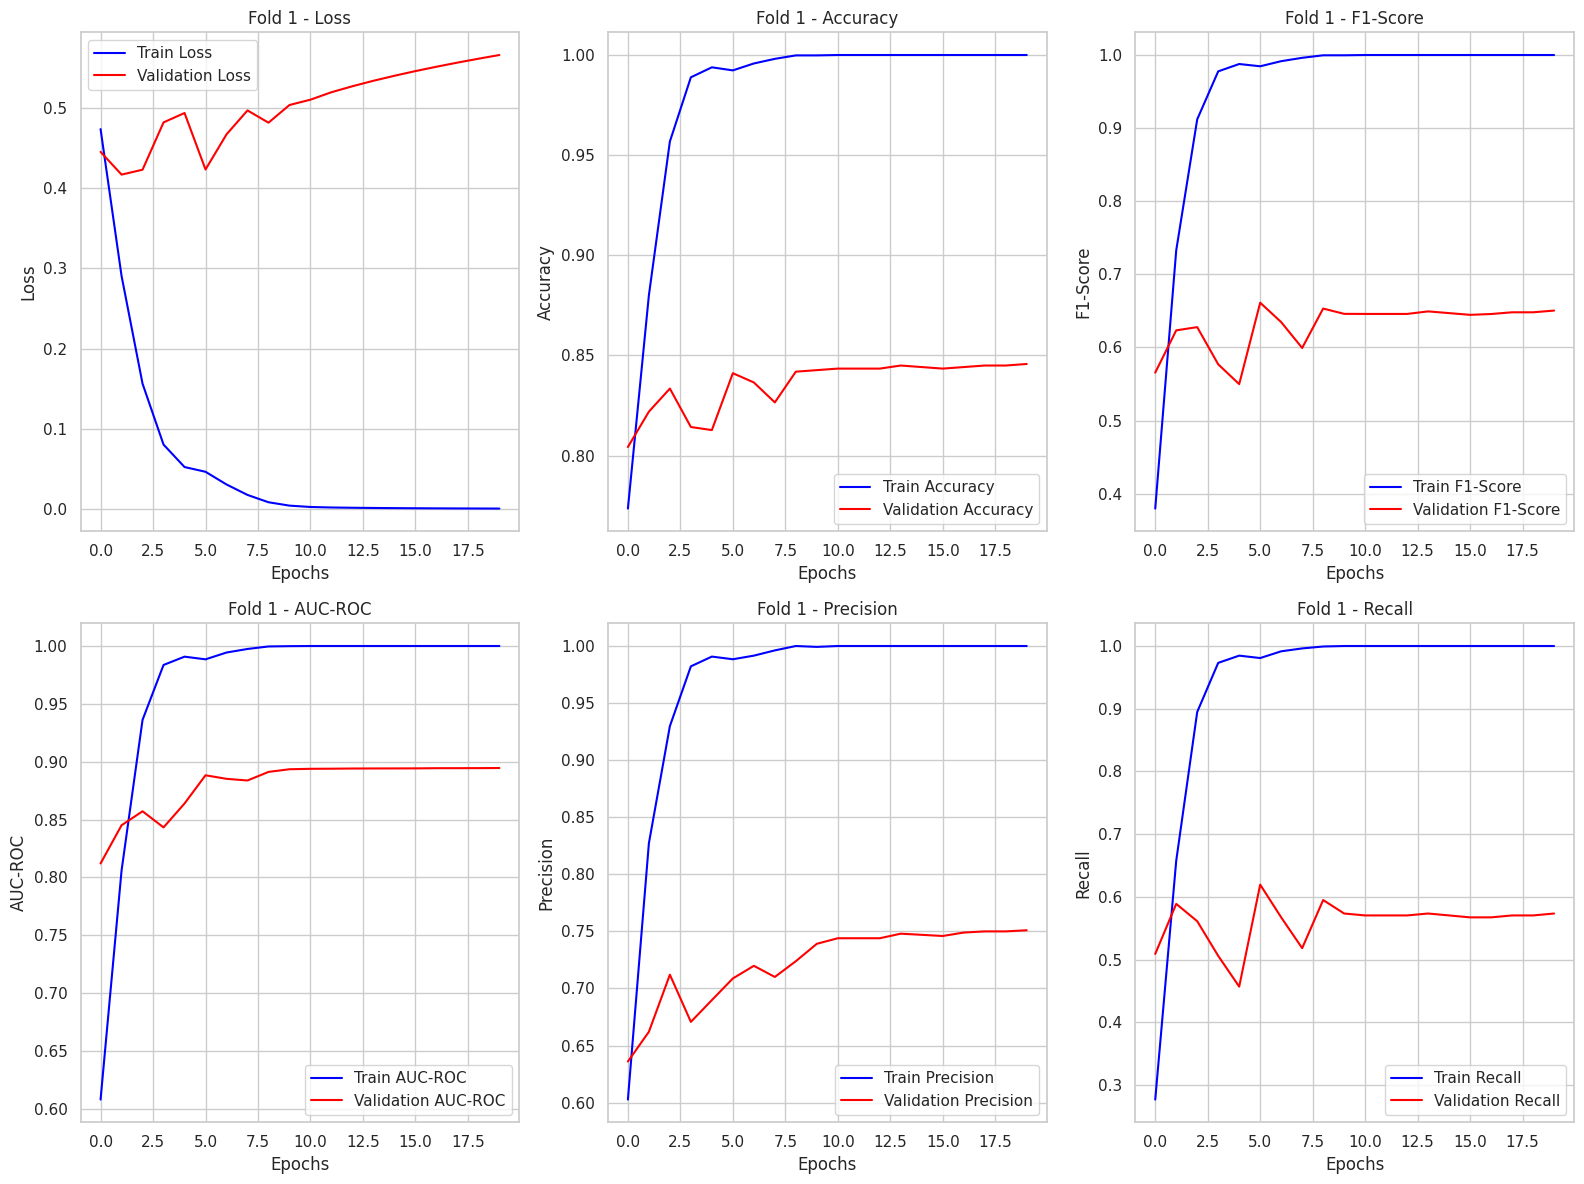

Epoch [10/20], Train Loss: 0.0030, Validation Loss: 0.4496, Validation Accuracy: 0.8488
Epoch [20/20], Train Loss: 0.0007, Validation Loss: 0.4904, Validation Accuracy: 0.8534


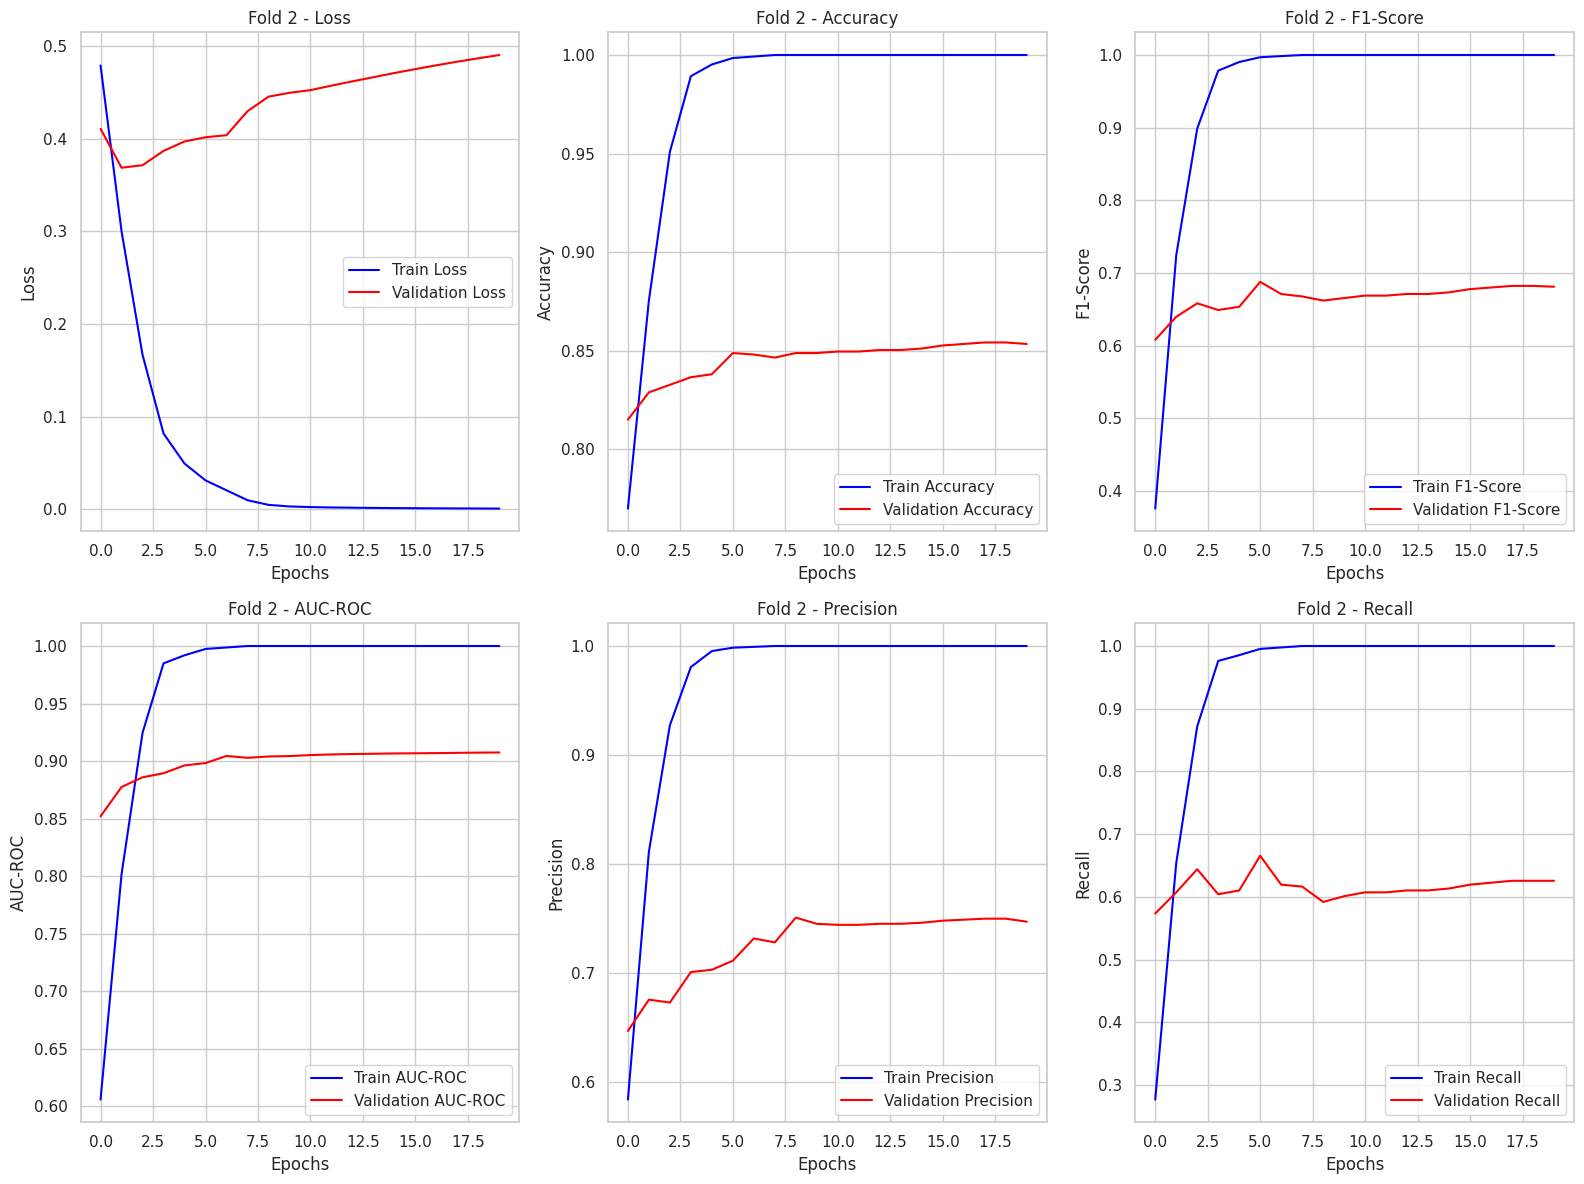

Epoch [10/20], Train Loss: 0.0032, Validation Loss: 0.4604, Validation Accuracy: 0.8503
Epoch [20/20], Train Loss: 0.0008, Validation Loss: 0.5149, Validation Accuracy: 0.8503


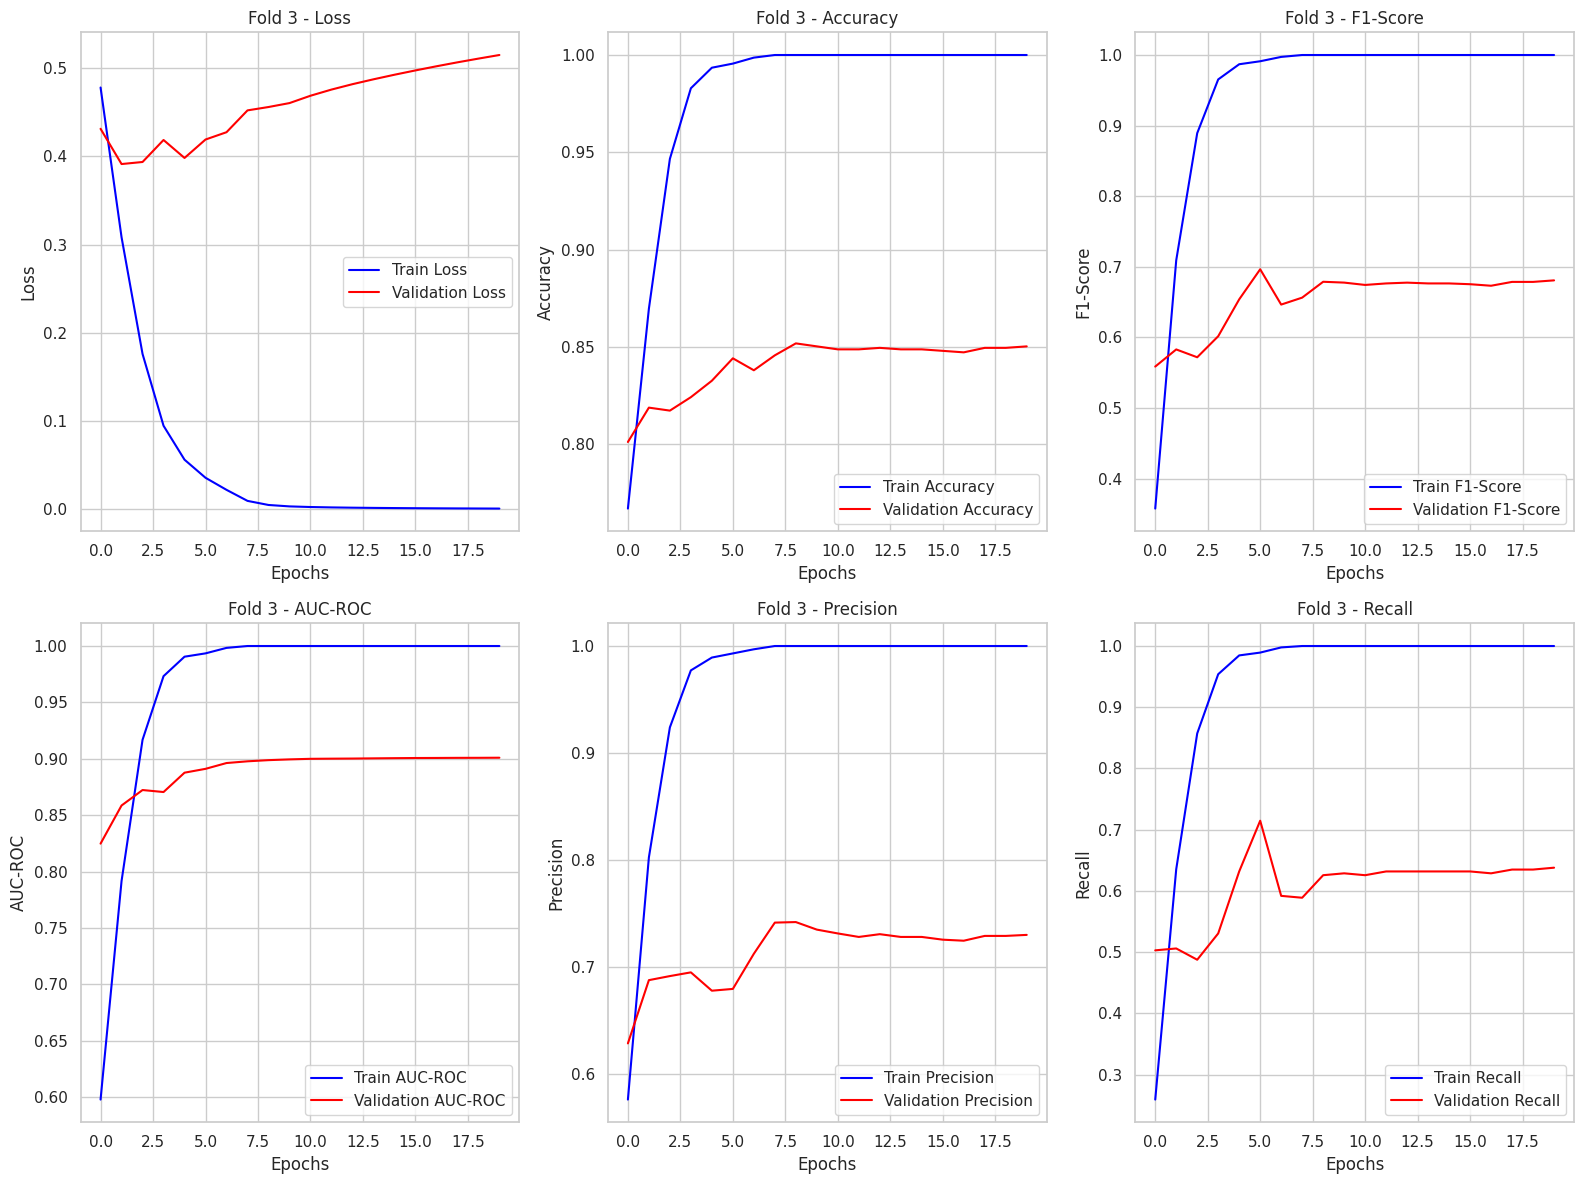

Epoch [10/20], Train Loss: 0.0032, Validation Loss: 0.5388, Validation Accuracy: 0.8289
Epoch [20/20], Train Loss: 0.0007, Validation Loss: 0.5964, Validation Accuracy: 0.8281


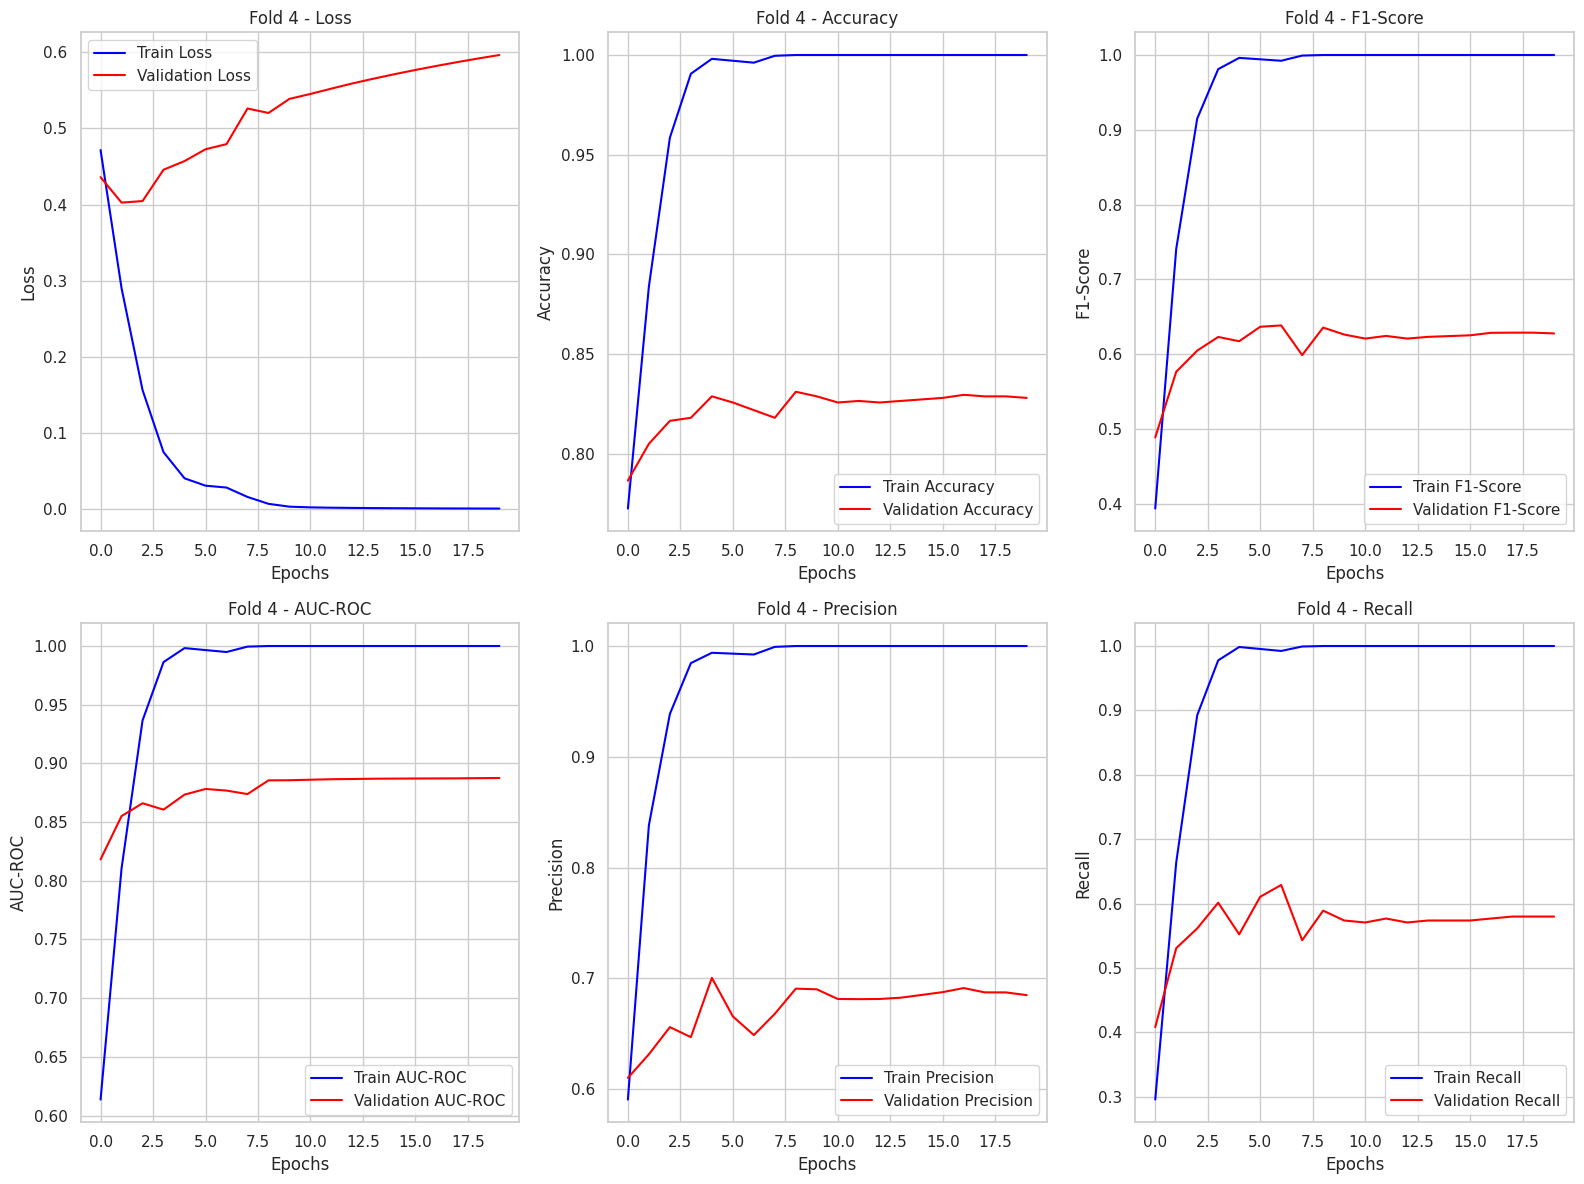

Epoch [10/20], Train Loss: 0.0031, Validation Loss: 0.4797, Validation Accuracy: 0.8418
Epoch [20/20], Train Loss: 0.0007, Validation Loss: 0.5322, Validation Accuracy: 0.8441


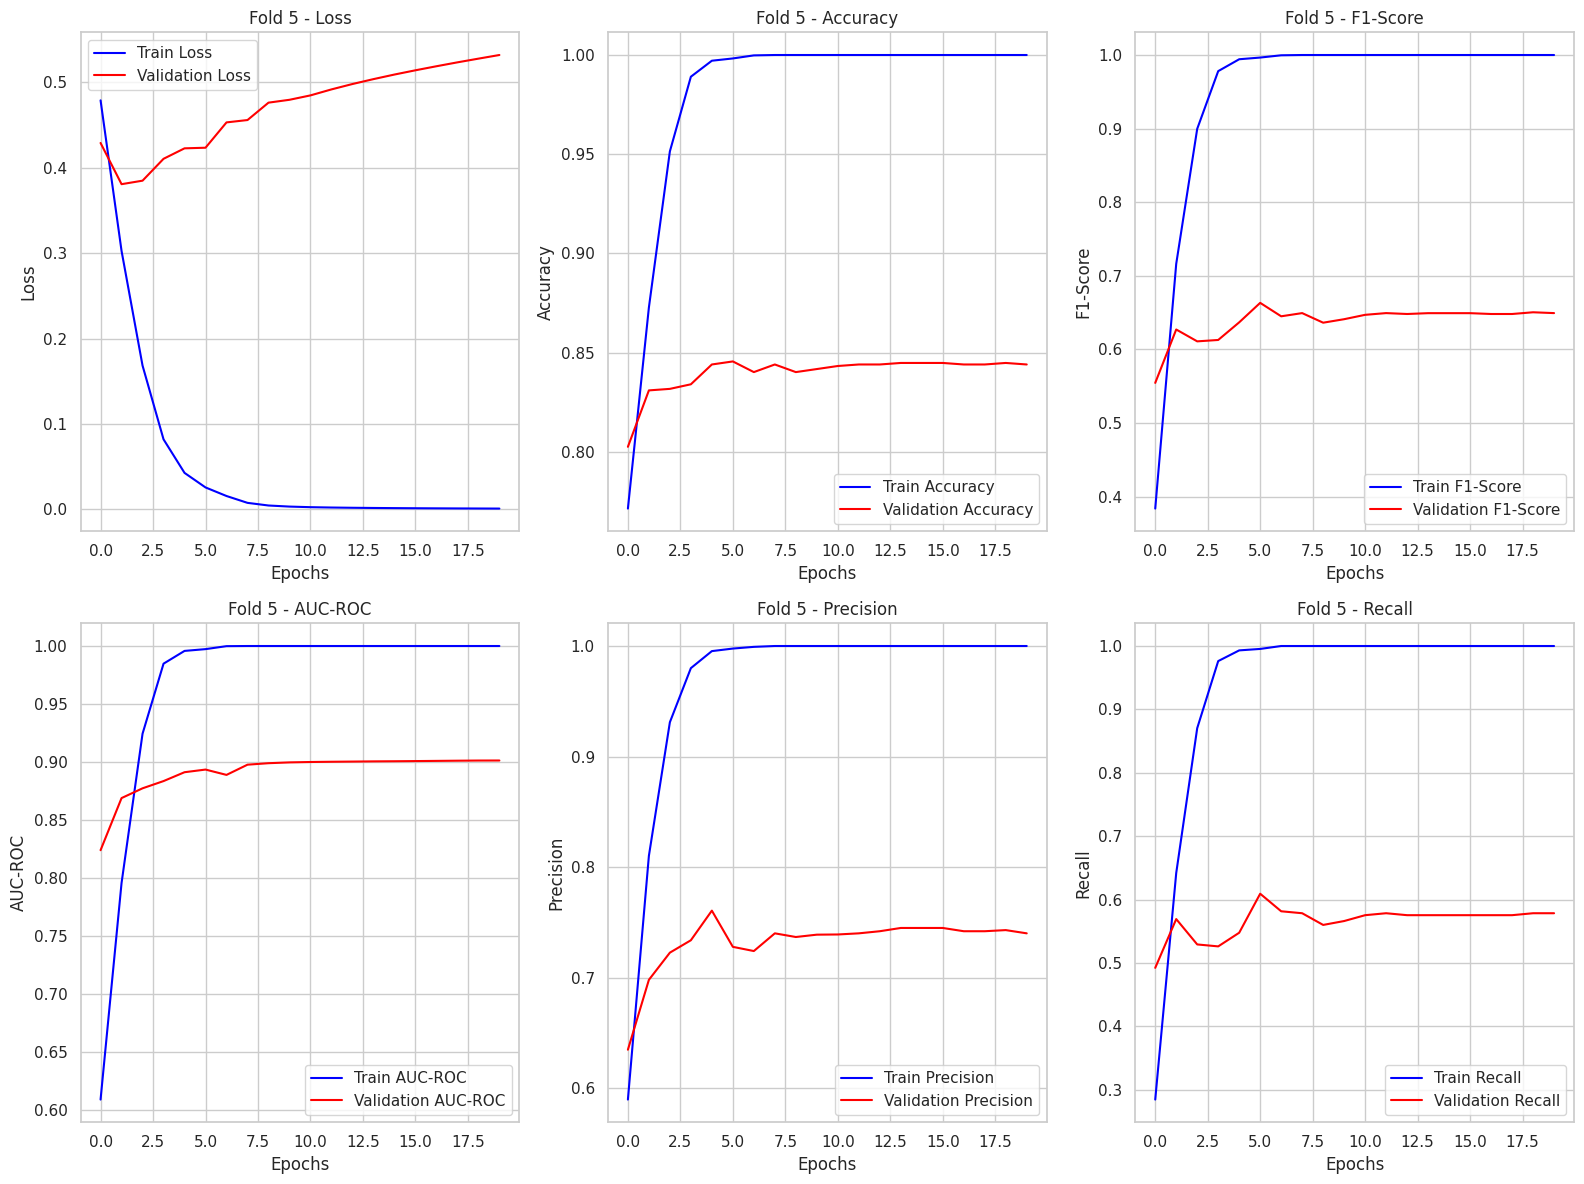

In [303]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

# 모델 학습 함수 정의 (수정된 부분 포함)
def train_model(model, final_embeddings, labels, X_val, y_val, epochs=20, batch_size=64):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    # 성능 추적을 위한 리스트
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    f1_train, f1_val = [], []
    auc_roc_train, auc_roc_val = [], []
    precision_train, precision_val = [], []
    recall_train, recall_val = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        correct_train = 0
        total_train = 0
        all_preds_train = []
        all_labels_train = []
        
        for i in range(0, len(final_embeddings), batch_size):
            batch_x = torch.tensor(final_embeddings[i:i + batch_size], dtype=torch.float32).to(device)
            batch_y = torch.tensor(labels[i:i + batch_size], dtype=torch.float32).to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y.view(-1, 1))
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()

            # Train accuracy 계산
            preds_train = torch.sigmoid(outputs).detach().cpu().numpy()
            preds_train_binary = (preds_train > 0.5).astype(int)
            correct_train += (preds_train_binary.flatten() == batch_y.cpu().numpy()).sum()
            total_train += len(batch_y)

            # F1, Precision, Recall 계산
            all_preds_train.extend(preds_train_binary.flatten())
            all_labels_train.extend(batch_y.cpu().numpy())

        # 성능 지표 계산
        train_losses.append(epoch_train_loss / (len(final_embeddings) // batch_size))
        train_accuracies.append(correct_train / total_train)

        f1_train.append(f1_score(all_labels_train, all_preds_train))
        precision_train.append(precision_score(all_labels_train, all_preds_train))
        recall_train.append(recall_score(all_labels_train, all_preds_train))
        auc_roc_train.append(roc_auc_score(all_labels_train, all_preds_train))

        # Validation step
        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.tensor(X_val, dtype=torch.float32).to(device))
            val_loss = criterion(val_outputs, torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device))
            val_losses.append(val_loss.item())

            # Validation accuracy 계산
            val_preds = torch.sigmoid(val_outputs).detach().cpu().numpy()
            val_preds_binary = (val_preds > 0.5).astype(int)
            correct_val = (val_preds_binary.flatten() == y_val).sum()
            val_accuracy = correct_val / len(y_val)
            val_accuracies.append(val_accuracy)

            # Validation F1, Precision, Recall, AUC-ROC 계산
            f1_val.append(f1_score(y_val, val_preds_binary))
            precision_val.append(precision_score(y_val, val_preds_binary))
            recall_val.append(recall_score(y_val, val_preds_binary))
            auc_roc_val.append(roc_auc_score(y_val, val_preds))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")

    return (train_losses, val_losses, train_accuracies, val_accuracies,
            f1_train, f1_val, auc_roc_train, auc_roc_val, precision_train, precision_val, recall_train, recall_val)


# 성능 시각화 (각 fold마다 다른 그래프에 표시)
train_losses_list = []
val_losses_list = []
train_accuracies_list = []
val_accuracies_list = []
f1_train_list = []
f1_val_list = []
auc_roc_train_list = []
auc_roc_val_list = []
precision_train_list = []
precision_val_list = []
recall_train_list = []
recall_val_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 각 fold마다 시드 고정 (필요 시)
    seed_everything(seed)
    
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # RNN 모델 초기화
    gru_model = GRUModel(input_dim=X.shape[1], hidden_dim=128, output_dim=1)

    # 모델 학습
    (train_losses, val_losses, train_accuracies, val_accuracies,
     f1_train, f1_val, auc_roc_train, auc_roc_val, precision_train, precision_val, recall_train, recall_val) = train_model(
         gru_model, X_fold_train, y_fold_train, X_fold_val, y_fold_val)

    # 각 fold에 대한 성능 결과 저장
    train_losses_list.append(train_losses)
    val_losses_list.append(val_losses)
    train_accuracies_list.append(train_accuracies)
    val_accuracies_list.append(val_accuracies)
    f1_train_list.append(f1_train)
    f1_val_list.append(f1_val)
    auc_roc_train_list.append(auc_roc_train)
    auc_roc_val_list.append(auc_roc_val)
    precision_train_list.append(precision_train)
    precision_val_list.append(precision_val)
    recall_train_list.append(recall_train)
    recall_val_list.append(recall_val)

    # 각 fold마다 그래프 그리기
    plt.figure(figsize=(16, 12))

    # Loss 그래프
    plt.subplot(2, 3, 1)
    plt.plot(train_losses, label="Train Loss", color='blue')
    plt.plot(val_losses, label="Validation Loss", color='red')
    plt.title(f"Fold {fold + 1} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy 그래프
    plt.subplot(2, 3, 2)
    plt.plot(train_accuracies, label="Train Accuracy", color='blue')
    plt.plot(val_accuracies, label="Validation Accuracy", color='red')
    plt.title(f"Fold {fold + 1} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # F1-Score 그래프
    plt.subplot(2, 3, 3)
    plt.plot(f1_train, label="Train F1-Score", color='blue')
    plt.plot(f1_val, label="Validation F1-Score", color='red')
    plt.title(f"Fold {fold + 1} - F1-Score")
    plt.xlabel("Epochs")
    plt.ylabel("F1-Score")
    plt.legend()

    # AUC-ROC 그래프
    plt.subplot(2, 3, 4)
    plt.plot(auc_roc_train, label="Train AUC-ROC", color='blue')
    plt.plot(auc_roc_val, label="Validation AUC-ROC", color='red')
    plt.title(f"Fold {fold + 1} - AUC-ROC")
    plt.xlabel("Epochs")
    plt.ylabel("AUC-ROC")
    plt.legend()

    # Precision 그래프
    plt.subplot(2, 3, 5)
    plt.plot(precision_train, label="Train Precision", color='blue')
    plt.plot(precision_val, label="Validation Precision", color='red')
    plt.title(f"Fold {fold + 1} - Precision")
    plt.xlabel("Epochs")
    plt.ylabel("Precision")
    plt.legend()

    # Recall 그래프
    plt.subplot(2, 3, 6)
    plt.plot(recall_train, label="Train Recall", color='blue')
    plt.plot(recall_val, label="Validation Recall", color='red')
    plt.title(f"Fold {fold + 1} - Recall")
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()

    # 그래프 표시
    plt.tight_layout()
    plt.show()

Transformer

In [253]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=4, num_layers=2, dim_feedforward=512, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)  # 입력 차원을 모델 차원으로 변환
        self.pos_encoder = nn.Sequential(
            nn.Embedding(5000, d_model),  # Positional Encoding (고정된 max_len)
            nn.Dropout(dropout)
        )
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout),
            num_layers=num_layers
        )
        self.fc = nn.Linear(d_model, 1)
        self.sigmoid = nn.Sigmoid()  # Binary classification용
        
    def forward(self, x):
        # 데이터가 2D일 경우, seq_len을 1로 설정하여 3D로 변환 (batch_size, seq_len, input_dim)
        batch_size = x.size(0)
        seq_len = 1  # 각 샘플은 하나의 시퀀스로 취급
        x = x.unsqueeze(1)  # (batch_size, 1, input_dim)
        
        x = self.embedding(x)  # (batch_size, 1, d_model)
        
        # Positional Encoding 추가
        position = torch.arange(seq_len).unsqueeze(0).repeat(batch_size, 1).to(x.device)
        x = x + self.pos_encoder[0](position)  # Add positional encodings
        
        x = self.transformer(x)  # Transformer Encoder
        x = x.mean(dim=1)  # Sequence 차원을 평균으로 줄임 (Global Average Pooling)
        out = self.fc(x)
        return self.sigmoid(out)

In [291]:
# Transformer 모델 학습 반복문
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 각 fold마다 시드 고정
    seed_everything(seed)
    
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # Transformer 모델 초기화
    transformer_model = TransformerModel(input_dim=X.shape[1], d_model=128, nhead=4, num_layers=2)

    # 모델 학습
    train_model(transformer_model, X_fold_train, y_fold_train, X_fold_val, y_fold_val)

    # Train 성능 평가
    transformer_train_report, transformer_train_auc, transformer_train_specificity = evaluate_model(transformer_model, X_fold_train, y_fold_train)
    
    # Validation 성능 평가
    transformer_val_report, transformer_val_auc, transformer_val_specificity = evaluate_model(transformer_model, X_fold_val, y_fold_val)
    
    # Train 성능 결과 저장
    train_row = pd.DataFrame({
        'Model': ['Transformer'],
        'Fold': [fold + 1],
        'Dataset': ['Train'],
        'Accuracy': [transformer_train_report['accuracy']],
        'F1-Score': [transformer_train_report['1']['f1-score']],
        'Precision': [transformer_train_report['1']['precision']],
        'Recall': [transformer_train_report['1']['recall']],
        'AUC-ROC': [transformer_train_auc],
        'Specificity': [transformer_train_specificity]
    })
    performance_df = pd.concat([performance_df, train_row], ignore_index=True)
    
    # Validation 성능 결과 저장
    val_row = pd.DataFrame({
        'Model': ['Transformer'],
        'Fold': [fold + 1],
        'Dataset': ['Validation'],
        'Accuracy': [transformer_val_report['accuracy']],
        'F1-Score': [transformer_val_report['1']['f1-score']],
        'Precision': [transformer_val_report['1']['precision']],
        'Recall': [transformer_val_report['1']['recall']],
        'AUC-ROC': [transformer_val_auc],
        'Specificity': [transformer_val_specificity]
    })
    performance_df_val = pd.concat([performance_df_val, val_row], ignore_index=True)

# 성능 데이터프레임 출력
performance_df

/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [10/40], Validation Loss: 0.6931
Epoch [20/40], Validation Loss: 0.6931
Epoch [30/40], Validation Loss: 0.6931
Epoch [40/40], Validation Loss: 0.6931


/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

Epoch [10/40], Validation Loss: 0.6932
Epoch [20/40], Validation Loss: 0.6931
Epoch [30/40], Validation Loss: 0.6931
Epoch [40/40], Validation Loss: 0.6931


/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

...

Epoch [10/40], Validation Loss: 0.6932
Epoch [20/40], Validation Loss: 0.6931
Epoch [30/40], Validation Loss: 0.6931
Epoch [40/40], Validation Loss: 0.6931


/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

Epoch [10/40], Validation Loss: 0.6932
Epoch [20/40], Validation Loss: 0.6931
Epoch [30/40], Validation Loss: 0.6931
Epoch [40/40], Validation Loss: 0.6931


/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alsghk01/다운로드/줄거리를 통한 도서 평점 예측2/myenv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,RNN,1,Train,0.999616,0.999233,0.999233,0.999233,0.999998,0.999744
1,RNN,2,Train,0.998849,0.997698,0.997698,0.997698,0.999998,0.999232
2,RNN,3,Train,0.999040,0.998081,0.998464,0.997698,0.999996,0.999488
3,RNN,4,Train,0.999232,0.998465,0.998465,0.998465,0.999998,0.999488
4,RNN,5,Train,0.999233,0.998465,0.999232,0.997699,0.999997,0.999744
5,LSTM,1,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,LSTM,2,Train,0.999808,0.999616,1.000000,0.999233,1.000000,1.000000
7,LSTM,3,Train,0.999808,0.999616,1.000000,0.999233,1.000000,1.000000
8,LSTM,4,Train,0.999616,0.999232,1.000000,0.998465,1.000000,1.000000
9,LSTM,5,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [292]:
performance_df_val

,Model,Fold,Dataset,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Specificity
0,RNN,1,Validation,0.853415,0.684298,0.741935,0.634969,0.906202,0.926305
1,RNN,2,Validation,0.861090,0.714060,0.736156,0.693252,0.913680,0.917093
2,RNN,3,Validation,0.866462,0.715686,0.765734,0.671779,0.910845,0.931423
3,RNN,4,Validation,0.843438,0.679245,0.696774,0.662577,0.901859,0.903787
4,RNN,5,Validation,0.864823,0.715210,0.754266,0.680000,0.916498,0.926305
5,LSTM,1,Validation,0.859555,0.687179,0.776062,0.616564,0.913539,0.940635
6,LSTM,2,Validation,0.870299,0.713073,0.798479,0.644172,0.920189,0.945752
7,LSTM,3,Validation,0.858787,0.692308,0.761029,0.634969,0.914782,0.933470
8,LSTM,4,Validation,0.838833,0.652318,0.708633,0.604294,0.903341,0.917093
9,LSTM,5,Validation,0.864055,0.701518,0.776119,0.640000,0.916306,0.938588


Text CNN